# Meme Stock Outage Event Study: GME & AMC — Four-Factor Model

**Objective:** Compute minute-level cumulative abnormal returns (CAR) for GameStop (GME) and
AMC Entertainment around Reddit (r/WallStreetBets) backend server outages, using a
**Fama-French four-factor event study design** to benchmark expected returns.

**Key date:** Robinhood trading restriction ban — January 28, 2021 at 09:30 AM ET.

**Outage events analyzed:**

| Event | Window | Duration | Period |
|-------|--------|----------|--------|
| Outage 1 | Jan 27, 11:29–13:40 | 131 min | Pre-Ban |
| Outage 2 | Jan 27, 16:03–17:01 | 58 min | Pre-Ban |
| Outage 3 | Jan 28, 08:44–10:51 | 127 min | Post-Ban |
| Outage 4 | Jan 28, 19:10–21:00 | 110 min | Post-Ban |

> **Note on factor availability:** Four-factor data (MKT_RF, SMB, HML, MOM) covers regular
> trading hours only (09:30–16:00 ET). Outages 2 and 4 fall after market close;
> CAR for those windows is computed only over minutes with available factor data.

---
## 1. Setup & Configuration

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import statsmodels.api as sm
from datetime import timedelta
from scipy.stats import mannwhitneyu
import warnings

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────
PROJECT_ROOT = pathlib.Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "Minute price and exceed return" / "output_data"
FF_DIR       = PROJECT_ROOT / "FF-Factors"
OUTPUT_DIR   = pathlib.Path.cwd() / "output" / "ff4"
FIGURES_DIR  = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, FIGURES_DIR, FIGURES_DIR / "gme", FIGURES_DIR / "amc"]:
    d.mkdir(parents=True, exist_ok=True)

# ── Stock column mappings ──────────────────────────────────────────────
STOCKS = {
    "GME": {
        "excess_return_file": "GME-minute_price-excess-return.csv",
        "price_col":  "gme_price",
        "return_col": "gme_return",
    },
    "AMC": {
        "excess_return_file": "AMC-minute_price-excess-return.csv",
        "price_col":  "amc_price",
        "return_col": "amc_return",
    },
}

# ── Event definitions ─────────────────────────────────────────────────
ROBINHOOD_BAN_DATE     = pd.Timestamp("2021-01-28 09:30:00")
ESTIMATION_WINDOW_DAYS = 120

OUTAGE_EVENTS = [
    {"name": "Outage 1 (Pre-Ban)",  "start": pd.Timestamp("2021-01-27 11:29:00"), "end": pd.Timestamp("2021-01-27 13:40:00"), "duration_minutes": 131},
    {"name": "Outage 2 (Pre-Ban)",  "start": pd.Timestamp("2021-01-27 16:03:00"), "end": pd.Timestamp("2021-01-27 17:01:00"), "duration_minutes": 58},
    {"name": "Outage 3 (Post-Ban)", "start": pd.Timestamp("2021-01-28 08:44:00"), "end": pd.Timestamp("2021-01-28 10:51:00"), "duration_minutes": 127},
    {"name": "Outage 4 (Post-Ban)", "start": pd.Timestamp("2021-01-28 19:10:00"), "end": pd.Timestamp("2021-01-28 21:00:00"), "duration_minutes": 110},
]

for evt in OUTAGE_EVENTS:
    midpoint = evt["start"] + (evt["end"] - evt["start"]) / 2
    evt["pre_ban"] = midpoint < ROBINHOOD_BAN_DATE

# ── Plot style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman"],
    "font.size":        12,
    "axes.linewidth":   1.2,
    "grid.alpha":       0.3,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "figure.dpi":       150,
    "savefig.bbox":     "tight",
    "savefig.dpi":      150,
})

PRE_BAN_COLOR  = "#D32F2F"   # red
POST_BAN_COLOR = "#1976D2"   # blue

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"FF dir:       {FF_DIR}")
print(f"Output dir:   {OUTPUT_DIR}")

Project root: /Users/rajvardhan/Desktop/Projects/RA-MemeStocks
Data dir:     /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Minute price and exceed return/output_data
FF dir:       /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/FF-Factors
Output dir:   /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/ff4


---
## 2. Load Data

### 2a. Stock Minute-Price & Excess Return Data

In [2]:
def load_stock_data(symbol):
    """Load excess-return CSV for a stock, returning a datetime-indexed DataFrame."""
    info = STOCKS[symbol]
    path = DATA_DIR / info["excess_return_file"]
    df = pd.read_csv(path, parse_dates=["datetime"])
    df = df.drop_duplicates(subset=["datetime"]).sort_values("datetime")
    df = df.set_index("datetime")
    return df


gme_data = load_stock_data("GME")
amc_data = load_stock_data("AMC")

print(f"GME: {len(gme_data):,} rows | columns: {list(gme_data.columns)}")
print(f"AMC: {len(amc_data):,} rows | columns: {list(amc_data.columns)}")
print(f"\nGME date range: {gme_data.index.min()} → {gme_data.index.max()}")
print(f"AMC date range: {amc_data.index.min()} → {amc_data.index.max()}")

GME: 99,878 rows | columns: ['gme_price', 'spy_price', 'gme_return', 'spy_return', 'excess_return', 'excess_return_cum_1min', 'excess_return_cum_5min', 'excess_return_cum_30min', 'excess_return_cum_1h', 'excess_return_cum_6h', 'excess_return_cum_1d', 'excess_return_cum_1w']
AMC: 105,370 rows | columns: ['spy_price', 'amc_price', 'spy_return', 'amc_return', 'excess_return', 'excess_return_cum_1min', 'excess_return_cum_5min', 'excess_return_cum_30min', 'excess_return_cum_1h', 'excess_return_cum_6h', 'excess_return_cum_1d', 'excess_return_cum_1w']

GME date range: 2020-11-02 04:01:00 → 2021-04-30 19:59:00
AMC date range: 2020-11-02 04:00:00 → 2021-04-30 19:59:00


In [3]:
gme_data.head()

,gme_price,spy_price,gme_return,spy_return,excess_return,excess_return_cum_1min,excess_return_cum_5min,excess_return_cum_30min,excess_return_cum_1h,excess_return_cum_6h,excess_return_cum_1d,excess_return_cum_1w
datetime,,,,,,,,,,,,
2020-11-02 04:01:00,10.40,328.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-02 04:02:00,10.48,328.60,0.007663,0.000365,0.007298,0.007298,0.007298,0.007298,0.007298,0.007298,0.007298,0.007298
2020-11-02 04:03:00,10.53,328.88,0.004760,0.000852,0.003908,0.003908,0.011206,0.011206,0.011206,0.011206,0.011206,0.011206
2020-11-02 04:12:00,10.65,328.98,0.011332,0.000304,0.011028,0.011028,0.011028,0.022233,0.022233,0.022233,0.022233,0.022233
2020-11-02 04:32:00,10.62,330.59,-0.002821,0.004882,-0.007703,-0.007703,-0.007703,0.007233,0.014530,0.014530,0.014530,0.014530


In [4]:
amc_data.head()

,spy_price,amc_price,spy_return,amc_return,excess_return,excess_return_cum_1min,excess_return_cum_5min,excess_return_cum_30min,excess_return_cum_1h,excess_return_cum_6h,excess_return_cum_1d,excess_return_cum_1w
datetime,,,,,,,,,,,,
2020-11-02 04:00:00,328.51,2.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-11-02 04:01:00,328.48,2.20,-0.000091,-0.022473,-0.022382,-0.022382,-0.022382,-0.022382,-0.022382,-0.022382,-0.022382,-0.022382
2020-11-02 04:02:00,328.60,2.28,0.000365,0.035718,0.035353,0.035353,0.012971,0.012971,0.012971,0.012971,0.012971,0.012971
2020-11-02 04:05:00,328.96,2.28,0.001095,0.000000,-0.001095,-0.001095,0.011876,0.011876,0.011876,0.011876,0.011876,0.011876
2020-11-02 04:06:00,328.94,2.28,-0.000061,0.000000,0.000061,0.000061,0.034319,0.011937,0.011937,0.011937,0.011937,0.011937


### 2b. Fama-French Four Factors (Minute Level)

The four factors are constructed from minute-level ETF prices:
- **MKT_RF** = log return of SPY (market proxy)
- **SMB** = log return of IWM − log return of VV (small minus big)
- **HML** = log return of VTV − log return of VUG (value minus growth)
- **MOM** = log return of MTUM (momentum ETF)

Factors are available only during regular trading hours: **09:30–16:00 ET**.

In [5]:
def load_ff_factors():
    """Load minute-level Fama-French four factors (09:30–16:00 ET only)."""
    path = FF_DIR / "ff_factors_20201101_20210430_minute.csv"
    ff = pd.read_csv(path, parse_dates=["datetime"])
    ff = ff.drop_duplicates(subset=["datetime"]).sort_values("datetime")
    ff = ff.set_index("datetime")
    return ff


ff_data = load_ff_factors()

print(f"FF factors: {len(ff_data):,} rows | columns: {list(ff_data.columns)}")
print(f"Date range: {ff_data.index.min()} → {ff_data.index.max()}")
print(f"\nDescriptive stats:")
ff_data.describe()

FF factors: 43,084 rows | columns: ['MKT_RF', 'SMB', 'HML', 'MOM']
Date range: 2020-11-02 09:31:00 → 2021-04-30 16:00:00

Descriptive stats:


,MKT_RF,SMB,HML,MOM
count,43084.000000,43084.000000,43084.000000,43084.000000
mean,0.000004,0.000003,0.000001,0.000003
std,0.000565,0.000788,0.000663,0.001040
min,-0.031372,-0.043452,-0.026506,-0.069630
25%,-0.000163,-0.000290,-0.000220,-0.000263
50%,0.000000,0.000005,-0.000002,0.000000
75%,0.000166,0.000297,0.000218,0.000272
max,0.037901,0.044927,0.049218,0.069832


---
## 3. Excess Return Time Series Visualization

Plot the full Nov 2020 – Apr 2021 minute-level excess returns (stock − SPY) for each stock,
with the Jan 27–28 outage cluster highlighted. These excess returns are used for visual
inspection; the formal event study uses four-factor model residuals.

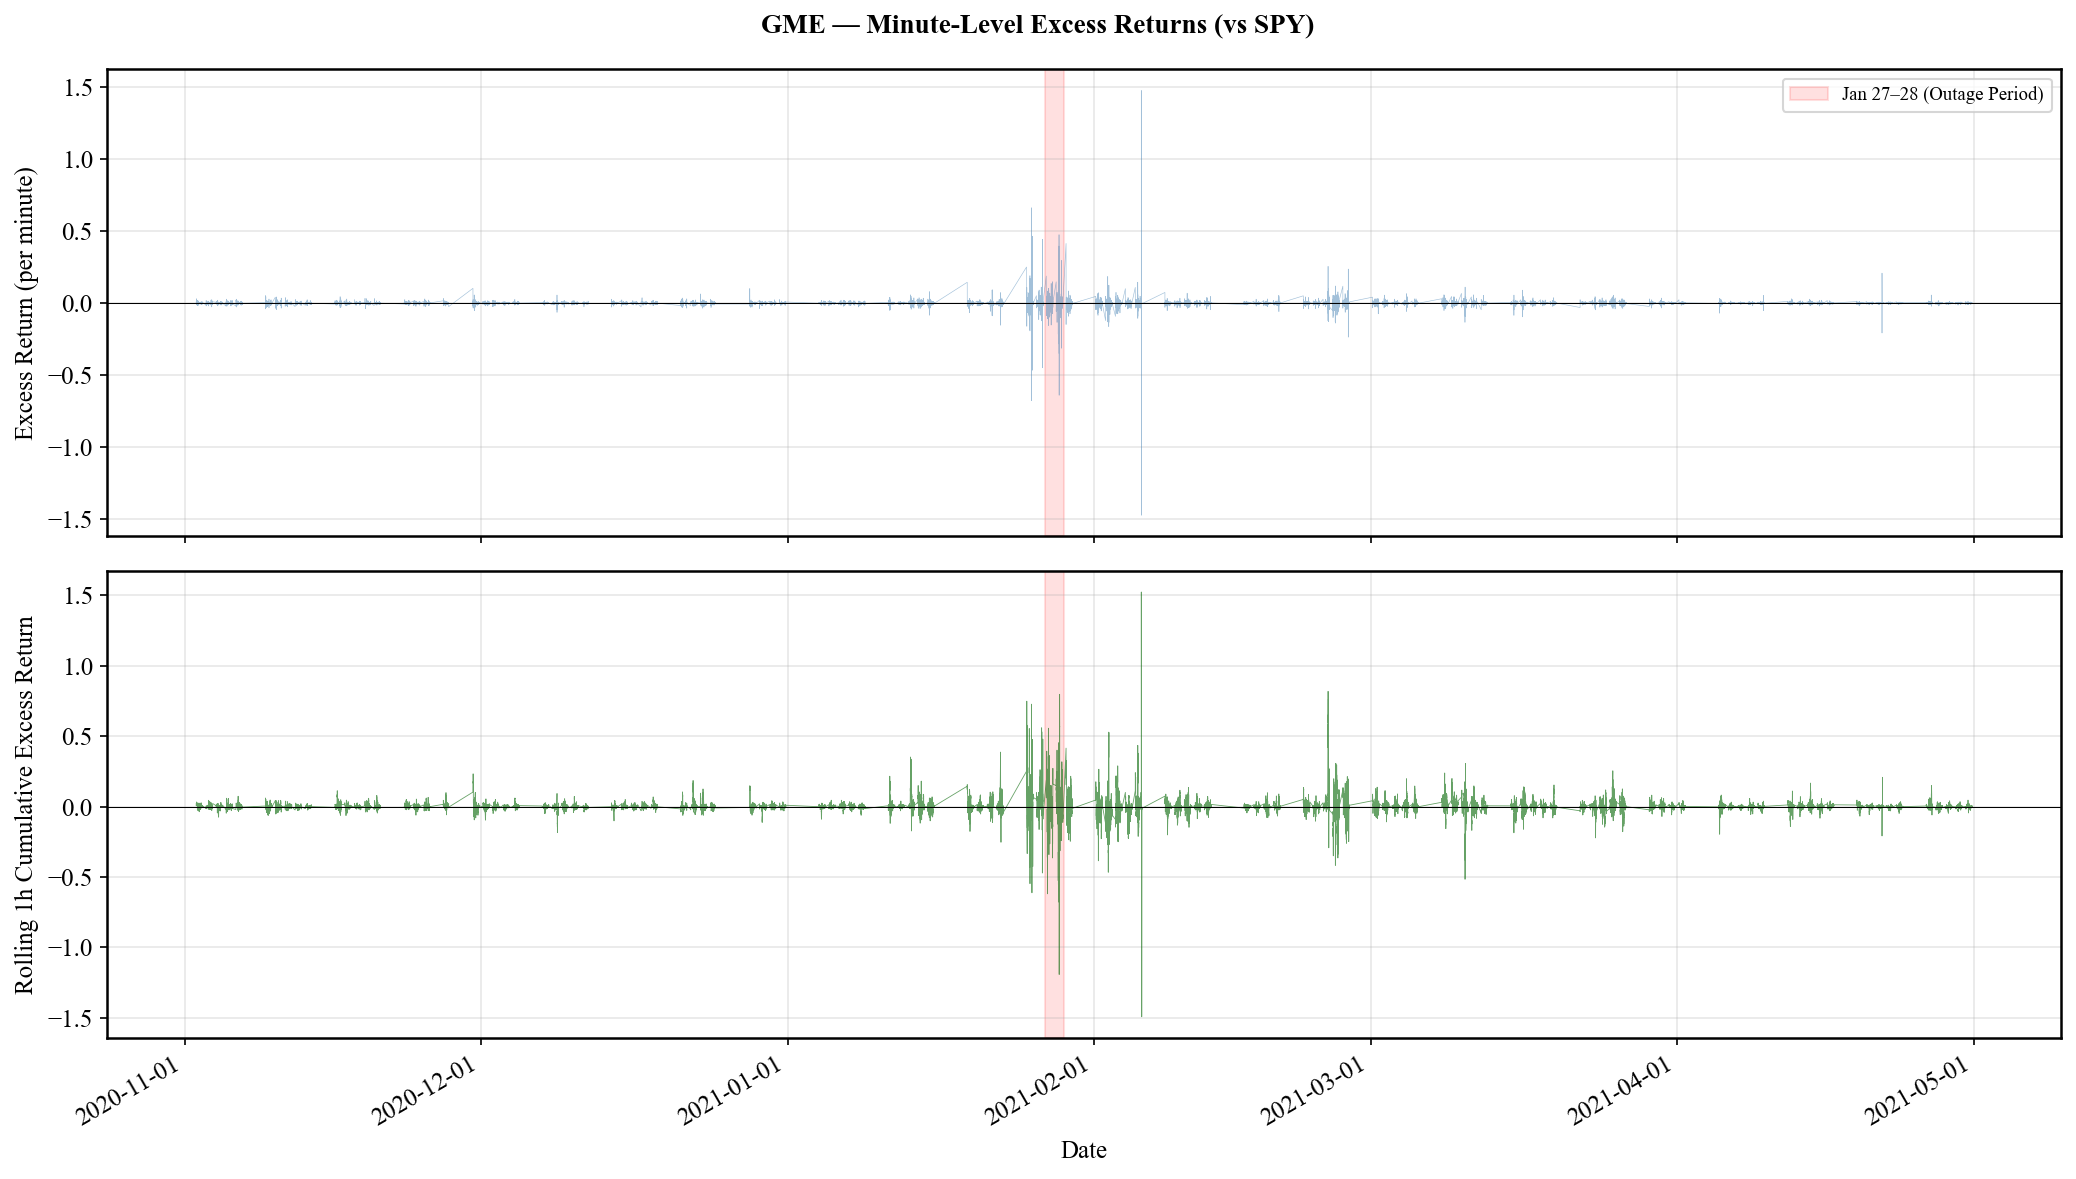

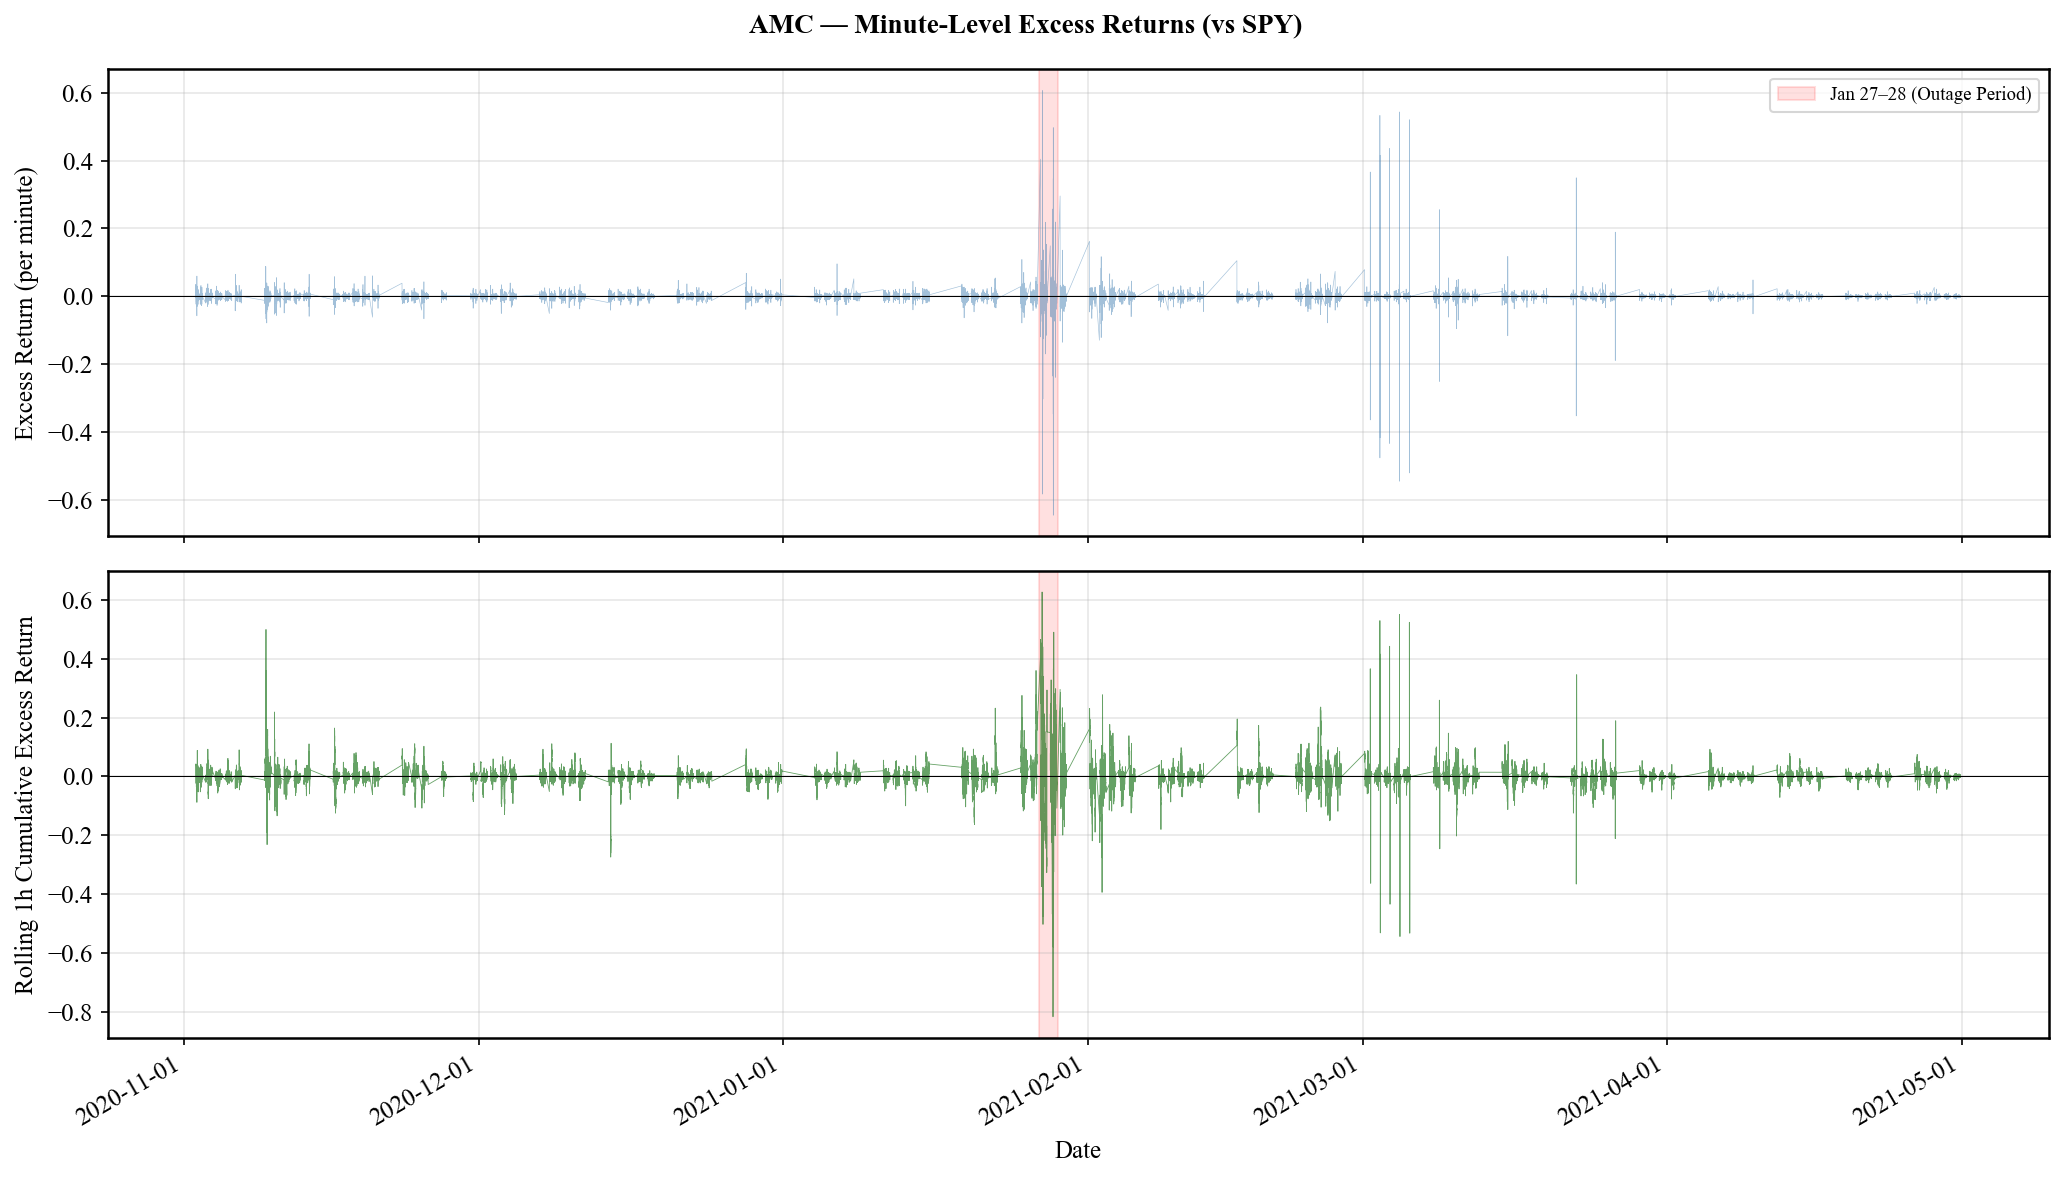

In [6]:
def plot_excess_return_timeseries(symbol, data):
    """Full Nov 2020 – Apr 2021 excess return with Jan 27-28 highlighted."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    fig.suptitle(f"{symbol} — Minute-Level Excess Returns (vs SPY)",
                 fontsize=13, fontweight="bold")

    cluster_start = pd.Timestamp("2021-01-27 00:00")
    cluster_end   = pd.Timestamp("2021-01-29 00:00")

    # Top: raw excess return
    ax1.plot(data.index, data["excess_return"], color="steelblue",
             alpha=0.5, linewidth=0.3)
    ax1.axhline(0, color="black", linewidth=0.5)
    ax1.axvspan(cluster_start, cluster_end, alpha=0.12, color="red",
                label="Jan 27–28 (Outage Period)")
    ax1.set_ylabel("Excess Return (per minute)")
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    # Bottom: rolling 1-hour cumulative excess return
    if "excess_return_cum_1h" in data.columns:
        ax2.plot(data.index, data["excess_return_cum_1h"], color="darkgreen",
                 alpha=0.6, linewidth=0.4)
        ax2.axhline(0, color="black", linewidth=0.5)
        ax2.axvspan(cluster_start, cluster_end, alpha=0.12, color="red")
    ax2.set_ylabel("Rolling 1h Cumulative Excess Return")
    ax2.set_xlabel("Date")
    ax2.grid(alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / symbol.lower() / "excess_return_timeseries.png")
    plt.show()


plot_excess_return_timeseries("GME", gme_data)
plot_excess_return_timeseries("AMC", amc_data)

The plots confirm that Jan 27–28 is an extreme outlier in both stocks' return histories.
GME and AMC show massive positive and then negative excess returns concentrated in that
two-day window — consistent with the short-squeeze dynamics and subsequent Reddit/Robinhood disruptions.

---
## 4. Four-Factor Model Estimation

Estimate the Fama-French four-factor model for each stock using a **120-day estimation window**
ending **2 days before** the first outage event ([-120, -2] window). Only regular-hours minutes
(09:30–16:00 ET) with available FF factor data are used in estimation (inner join):

$$R_{stock,t} = \alpha + \beta_{MKT} \cdot MKT\_RF_t + \beta_{SMB} \cdot SMB_t + \beta_{HML} \cdot HML_t + \beta_{MOM} \cdot MOM_t + \varepsilon_t$$

Where:
- **MKT_RF**: Market excess return (log SPY return)
- **SMB**: Size premium (IWM − VV log returns)
- **HML**: Value premium (VTV − VUG log returns)
- **MOM**: Momentum premium (MTUM log return)

The residual standard deviation $\sigma_{\varepsilon}$ captures idiosyncratic risk not explained by common factors.

In [7]:
def estimate_ff4(stock_data, symbol, ff_data, estimation_end,
                 window_days=ESTIMATION_WINDOW_DAYS):
    """
    Estimate Fama-French four-factor model over a pre-event estimation window.
    Uses an inner join with FF factors (restricts to regular trading hours).

    Returns dict with factor loadings, residual_std, r_squared, n_obs.
    """
    estimation_start = estimation_end - timedelta(days=window_days)
    window = stock_data.loc[estimation_start:estimation_end].copy()

    # Inner join — keeps only minutes with FF factor data (09:30–16:00 only)
    window = window.join(ff_data[["MKT_RF", "SMB", "HML", "MOM"]], how="inner")
    window = window.dropna(
        subset=[STOCKS[symbol]["return_col"], "MKT_RF", "SMB", "HML", "MOM"]
    )

    y = window[STOCKS[symbol]["return_col"]]
    X = sm.add_constant(window[["MKT_RF", "SMB", "HML", "MOM"]])
    model = sm.OLS(y, X, missing="drop").fit()

    return {
        "alpha":        model.params.get("const",  0.0),
        "beta_mkt":     model.params.get("MKT_RF", 0.0),
        "beta_smb":     model.params.get("SMB",    0.0),
        "beta_hml":     model.params.get("HML",    0.0),
        "beta_mom":     model.params.get("MOM",    0.0),
        "residual_std": np.sqrt(model.mse_resid),
        "r_squared":    model.rsquared,
        "n_obs":        int(model.nobs),
    }


# Estimation window: 120 days ending 2 days before the first outage ([-120, -2])
first_event_start = min(e["start"] for e in OUTAGE_EVENTS)
estimation_end    = first_event_start - timedelta(days=2)

print(f"Estimation window: {estimation_end - timedelta(days=ESTIMATION_WINDOW_DAYS)} → {estimation_end}\n")

gme_params = estimate_ff4(gme_data, "GME", ff_data, estimation_end)
amc_params = estimate_ff4(amc_data, "AMC", ff_data, estimation_end)

for sym, params in [("GME", gme_params), ("AMC", amc_params)]:
    print(f"{sym} Four-Factor Model:")
    print(f"  alpha    = {params['alpha']:.6f}")
    print(f"  beta_mkt = {params['beta_mkt']:.4f}")
    print(f"  beta_smb = {params['beta_smb']:.4f}")
    print(f"  beta_hml = {params['beta_hml']:.4f}")
    print(f"  beta_mom = {params['beta_mom']:.4f}")
    print(f"  R²       = {params['r_squared']:.4f}")
    print(f"  n_obs    = {params['n_obs']:,}")
    print(f"  sigma_e  = {params['residual_std']:.6f}\n")

Estimation window: 2020-09-27 11:29:00 → 2021-01-25 11:29:00

GME Four-Factor Model:
  alpha    = 0.000053
  beta_mkt = 0.1592
  beta_smb = 0.7944
  beta_hml = -0.5291
  beta_mom = 0.4511
  R²       = 0.0185
  n_obs    = 18,854
  sigma_e  = 0.005659

AMC Four-Factor Model:
  alpha    = -0.000057
  beta_mkt = 0.1210
  beta_smb = 0.2082
  beta_hml = -0.0860
  beta_mom = 0.0372
  R²       = 0.0016
  n_obs    = 18,893
  sigma_e  = 0.004792



**Interpretation:** The four-factor model improves on simple CAPM by controlling for size (SMB),
value (HML), and momentum (MOM) — factors historically correlated with returns. GME and AMC were
retail-driven, high-momentum stocks during this period, so MOM loading may be particularly
informative. Even with four factors, R² remains low for meme stocks, reflecting their extreme
idiosyncratic volatility. The large residual standard deviations confirm that common risk factors
explain only a small fraction of minute-level return variation.

---
## 5. Cumulative Abnormal Returns (CAR) Calculation

For each outage event window (start → end + 2 hours):
1. Left-join stock returns with FF factors (NaN for after-hours minutes)
2. **During trading hours (09:30–16:00):** Compute expected return using the full four-factor model:
   $$\hat{R}_t = \hat{\alpha} + \hat{\beta}_{MKT} \cdot MKT\_RF_t + \hat{\beta}_{SMB} \cdot SMB_t + \hat{\beta}_{HML} \cdot HML_t + \hat{\beta}_{MOM} \cdot MOM_t$$
3. **After hours (when FF factors are unavailable):** Fall back to the market model using SPY return as the MKT_RF proxy and setting SMB = HML = MOM = 0:
   $$\hat{R}_t = \hat{\alpha} + \hat{\beta}_{MKT} \cdot R_{SPY,t}$$
4. Compute **abnormal return**: $AR_t = R_t - \hat{R}_t$
5. Compute **cumulative abnormal return**: $CAR = \sum AR_t$

> This hybrid approach ensures all four outage events produce valid CARs, even those in
> after-hours windows (Outages 2 and 4), while using the full four-factor model wherever
> factor data is available.

In [8]:
def calculate_car(stock_data, ff_data, event, model_params, symbol,
                  pre_period_hours=1):
    """
    Calculate Cumulative Abnormal Return for a single outage event
    using the four-factor model.

    Includes a pre-period of `pre_period_hours` before the event start so that
    figures can show whether pre-trends exist. CAR is normalized to 0 at
    event_start so that the pre-period drift is visible but post-event metrics
    are unaffected.

    During trading hours (09:30–16:00): full four-factor expected return.
    After hours (factors unavailable): market-model fallback using SPY return
    as MKT_RF proxy and setting SMB = HML = MOM = 0.

    Returns a dict with summary metrics and the full event_data DataFrame,
    or None if no price data exists for the window.
    """
    event_start        = event["start"]
    event_end_extended = event["end"] + timedelta(hours=2)
    pre_period_start   = event_start - timedelta(hours=pre_period_hours)

    event_data = stock_data.loc[pre_period_start:event_end_extended].copy()
    if event_data.empty:
        return None

    return_col = STOCKS[symbol]["return_col"]
    price_col  = STOCKS[symbol]["price_col"]

    # Left-join FF factors (NaN for after-hours minutes)
    event_data = event_data.join(
        ff_data[["MKT_RF", "SMB", "HML", "MOM"]], how="left"
    )

    # After-hours fallback: substitute spy_return for MKT_RF, zero for SMB/HML/MOM
    factor_missing = event_data["MKT_RF"].isna()
    if factor_missing.any():
        event_data.loc[factor_missing, "MKT_RF"] = event_data.loc[factor_missing, "spy_return"]
        event_data.loc[factor_missing, "SMB"]    = 0.0
        event_data.loc[factor_missing, "HML"]    = 0.0
        event_data.loc[factor_missing, "MOM"]    = 0.0

    alpha    = model_params["alpha"]
    beta_mkt = model_params["beta_mkt"]
    beta_smb = model_params["beta_smb"]
    beta_hml = model_params["beta_hml"]
    beta_mom = model_params["beta_mom"]

    # Expected return (four-factor during market hours, market-model after hours)
    event_data["expected_return"] = (
        alpha
        + beta_mkt * event_data["MKT_RF"]
        + beta_smb * event_data["SMB"]
        + beta_hml * event_data["HML"]
        + beta_mom * event_data["MOM"]
    )
    event_data["ff_factors_available"] = ~factor_missing

    event_data["AR"] = event_data[return_col] - event_data["expected_return"]

    # Compute cumulative AR from pre-period start, then normalize so CAR = 0
    # at event_start — this preserves all post-event metrics while allowing
    # the pre-period to reveal any pre-trends.
    event_data["CAR_raw"] = event_data["AR"].cumsum()
    pre_mask = event_data.index <= event_start
    car_offset = event_data.loc[pre_mask, "CAR_raw"].iloc[-1] if pre_mask.any() else 0.0
    event_data["CAR"] = event_data["CAR_raw"] - car_offset

    event_data["time_from_start"] = (
        (event_data.index - event_start).total_seconds() / 60
    )

    # Helper: last CAR value at or before a target time
    def car_at(target_time):
        mask = event_data.index <= target_time
        if mask.any():
            return event_data.loc[mask, "CAR"].iloc[-1]
        return np.nan

    car_30min       = car_at(event_start + timedelta(minutes=30))
    car_1h          = car_at(event_start + timedelta(hours=1))
    car_outage_end  = car_at(event["end"])
    car_end_plus_2h = event_data["CAR"].iloc[-1] if len(event_data) else np.nan

    # Price change during outage window
    outage_data = stock_data.loc[event_start:event["end"]]
    if len(outage_data) >= 2:
        p_start = outage_data[price_col].iloc[0]
        p_end   = outage_data[price_col].iloc[-1]
        price_change_pct = (p_end - p_start) / p_start * 100
    else:
        price_change_pct = np.nan

    # Flag whether this event window was fully or partially after-hours
    n_total   = len(event_data.loc[event_start:event["end"]])
    n_ff_mins = int(event_data.loc[event_start:event["end"], "ff_factors_available"].sum())

    return {
        "event_name":        event["name"],
        "start_time":        event["start"],
        "end_time":          event["end"],
        "pre_period_start":  pre_period_start,
        "duration_minutes":  event["duration_minutes"],
        "pre_ban":           event["pre_ban"],
        "CAR_30min":         car_30min,
        "CAR_1h":            car_1h,
        "CAR_at_outage_end": car_outage_end,
        "CAR_end_plus_2h":   car_end_plus_2h,
        "price_change_pct":  price_change_pct,
        "n_ff_minutes":      n_ff_mins,
        "n_total_minutes":   n_total,
        "event_data":        event_data,
    }


In [9]:
# Calculate CAR for all events, both stocks
all_results = {}

for symbol, data, params in [
    ("GME", gme_data, gme_params),
    ("AMC", amc_data, amc_params),
]:
    event_results = []
    for event in OUTAGE_EVENTS:
        result = calculate_car(data, ff_data, event, params, symbol)
        if result:
            event_results.append(result)
    all_results[symbol] = event_results

print(f"Computed CARs: {len(all_results['GME'])} GME events, {len(all_results['AMC'])} AMC events.")

Computed CARs: 4 GME events, 4 AMC events.


---
## 6. Results Summary Table

In [10]:
# Build results table
rows = []
for symbol, results in all_results.items():
    for r in results:
        rows.append({
            "Stock":              symbol,
            "Event":              r["event_name"],
            "Start":              r["start_time"],
            "End":                r["end_time"],
            "Duration (min)":     r["duration_minutes"],
            "Pre-Ban":            r["pre_ban"],
            "CAR @30min":         r["CAR_30min"],
            "CAR @1h":            r["CAR_1h"],
            "CAR @End":           r["CAR_at_outage_end"],
            "CAR @End+2h":        r["CAR_end_plus_2h"],
            "Price Change %":     r["price_change_pct"],
            "FF Mins / Total":    f"{r['n_ff_minutes']}/{r['n_total_minutes']}",
        })

results_df = pd.DataFrame(rows)

# Save to CSV
out_path = OUTPUT_DIR / "car_results_ff4.csv"
results_df.to_csv(out_path, index=False)
print(f"Results saved to {out_path}\n")

# Display
display_cols = ["Stock", "Event", "CAR @30min", "CAR @1h", "CAR @End",
                "Price Change %", "FF Mins / Total"]
results_df[display_cols].style.format({
    "CAR @30min":     "{:.4f}",
    "CAR @1h":        "{:.4f}",
    "CAR @End":       "{:.4f}",
    "Price Change %": "{:.2f}%",
}).set_caption(
    "Four-Factor Event Study Results: CAR Around Reddit Outages\n"
    "(FF Mins / Total = minutes with four-factor data / total outage minutes)"
)

Results saved to /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/ff4/car_results_ff4.csv



,Stock,Event,CAR @30min,CAR @1h,CAR @End,Price Change %,FF Mins / Total
0,GME,Outage 1 (Pre-Ban),-0.1480,-0.1839,-0.1201,-10.10%,128/128
1,GME,Outage 2 (Pre-Ban),-0.0880,-0.1394,-0.1498,-13.66%,0/59
2,GME,Outage 3 (Post-Ban),-0.3099,-0.1836,-0.3387,-28.89%,57/105
3,GME,Outage 4 (Post-Ban),-0.0594,-0.0956,-0.0956,-8.71%,0/51
4,AMC,Outage 1 (Pre-Ban),-0.1875,-0.1926,0.0058,0.04%,126/126
5,AMC,Outage 2 (Pre-Ban),-0.2079,-0.1766,-0.1664,-12.17%,0/59
6,AMC,Outage 3 (Post-Ban),-0.2040,-0.0037,-0.6260,-46.86%,51/101
7,AMC,Outage 4 (Post-Ban),-0.0153,-0.0868,-0.0868,-8.58%,0/50


**Key finding:** All CARs are largely negative — Reddit outages were associated with stock price
declines, consistent with the hypothesis that retail coordination via Reddit was supporting prices.
The four-factor model isolates outage-specific abnormal returns by controlling for broad market
movements (MKT_RF), size (SMB), value (HML), and momentum (MOM) effects.

---
## 7. Pre-Ban vs Post-Ban Comparison

Compare average CARs before and after the Robinhood trading restriction (January 28, 2021 09:30 ET).
Post-ban outages coincide with active selling pressure and already-disrupted trading, so larger
negative CARs are expected.

In [11]:
for symbol, results in all_results.items():
    print(f"\n{'='*55}")
    print(f"  {symbol}: Pre-Ban vs Post-Ban CAR Comparison")
    print(f"{'='*55}")

    pre_cars  = [r["CAR_at_outage_end"] for r in results if r["pre_ban"]]
    post_cars = [r["CAR_at_outage_end"] for r in results if not r["pre_ban"]]

    print(f"\nPre-ban  CARs:  {[f'{c:.4f}' for c in pre_cars]}")
    print(f"                → avg = {np.mean(pre_cars):.4f}")
    print(f"Post-ban CARs:  {[f'{c:.4f}' for c in post_cars]}")
    print(f"                → avg = {np.mean(post_cars):.4f}")
    print(f"\nDifference (Post − Pre): {np.mean(post_cars) - np.mean(pre_cars):.4f}")

    if len(pre_cars) >= 2 and len(post_cars) >= 2:
        stat, p = mannwhitneyu(pre_cars, post_cars, alternative="two-sided")
        print(f"Mann-Whitney U test: U = {stat:.4f},  p = {p:.4f}")
    else:
        print("\n(Insufficient observations per group for Mann-Whitney U test)")


  GME: Pre-Ban vs Post-Ban CAR Comparison

Pre-ban  CARs:  ['-0.1201', '-0.1498']
                → avg = -0.1349
Post-ban CARs:  ['-0.3387', '-0.0956']
                → avg = -0.2172

Difference (Post − Pre): -0.0822
Mann-Whitney U test: U = 2.0000,  p = 1.0000

  AMC: Pre-Ban vs Post-Ban CAR Comparison

Pre-ban  CARs:  ['0.0058', '-0.1664']
                → avg = -0.0803
Post-ban CARs:  ['-0.6260', '-0.0868']
                → avg = -0.3564

Difference (Post − Pre): -0.2761
Mann-Whitney U test: U = 3.0000,  p = 0.6667


---
## 8. Visualizations

### 8a. CAR Comparison Bar Charts (per stock)

2×2 panels showing CAR at 30 min, 1 hour, outage end, and raw price change.
Red = Pre-Ban events, Blue = Post-Ban events. Based on four-factor model residuals.

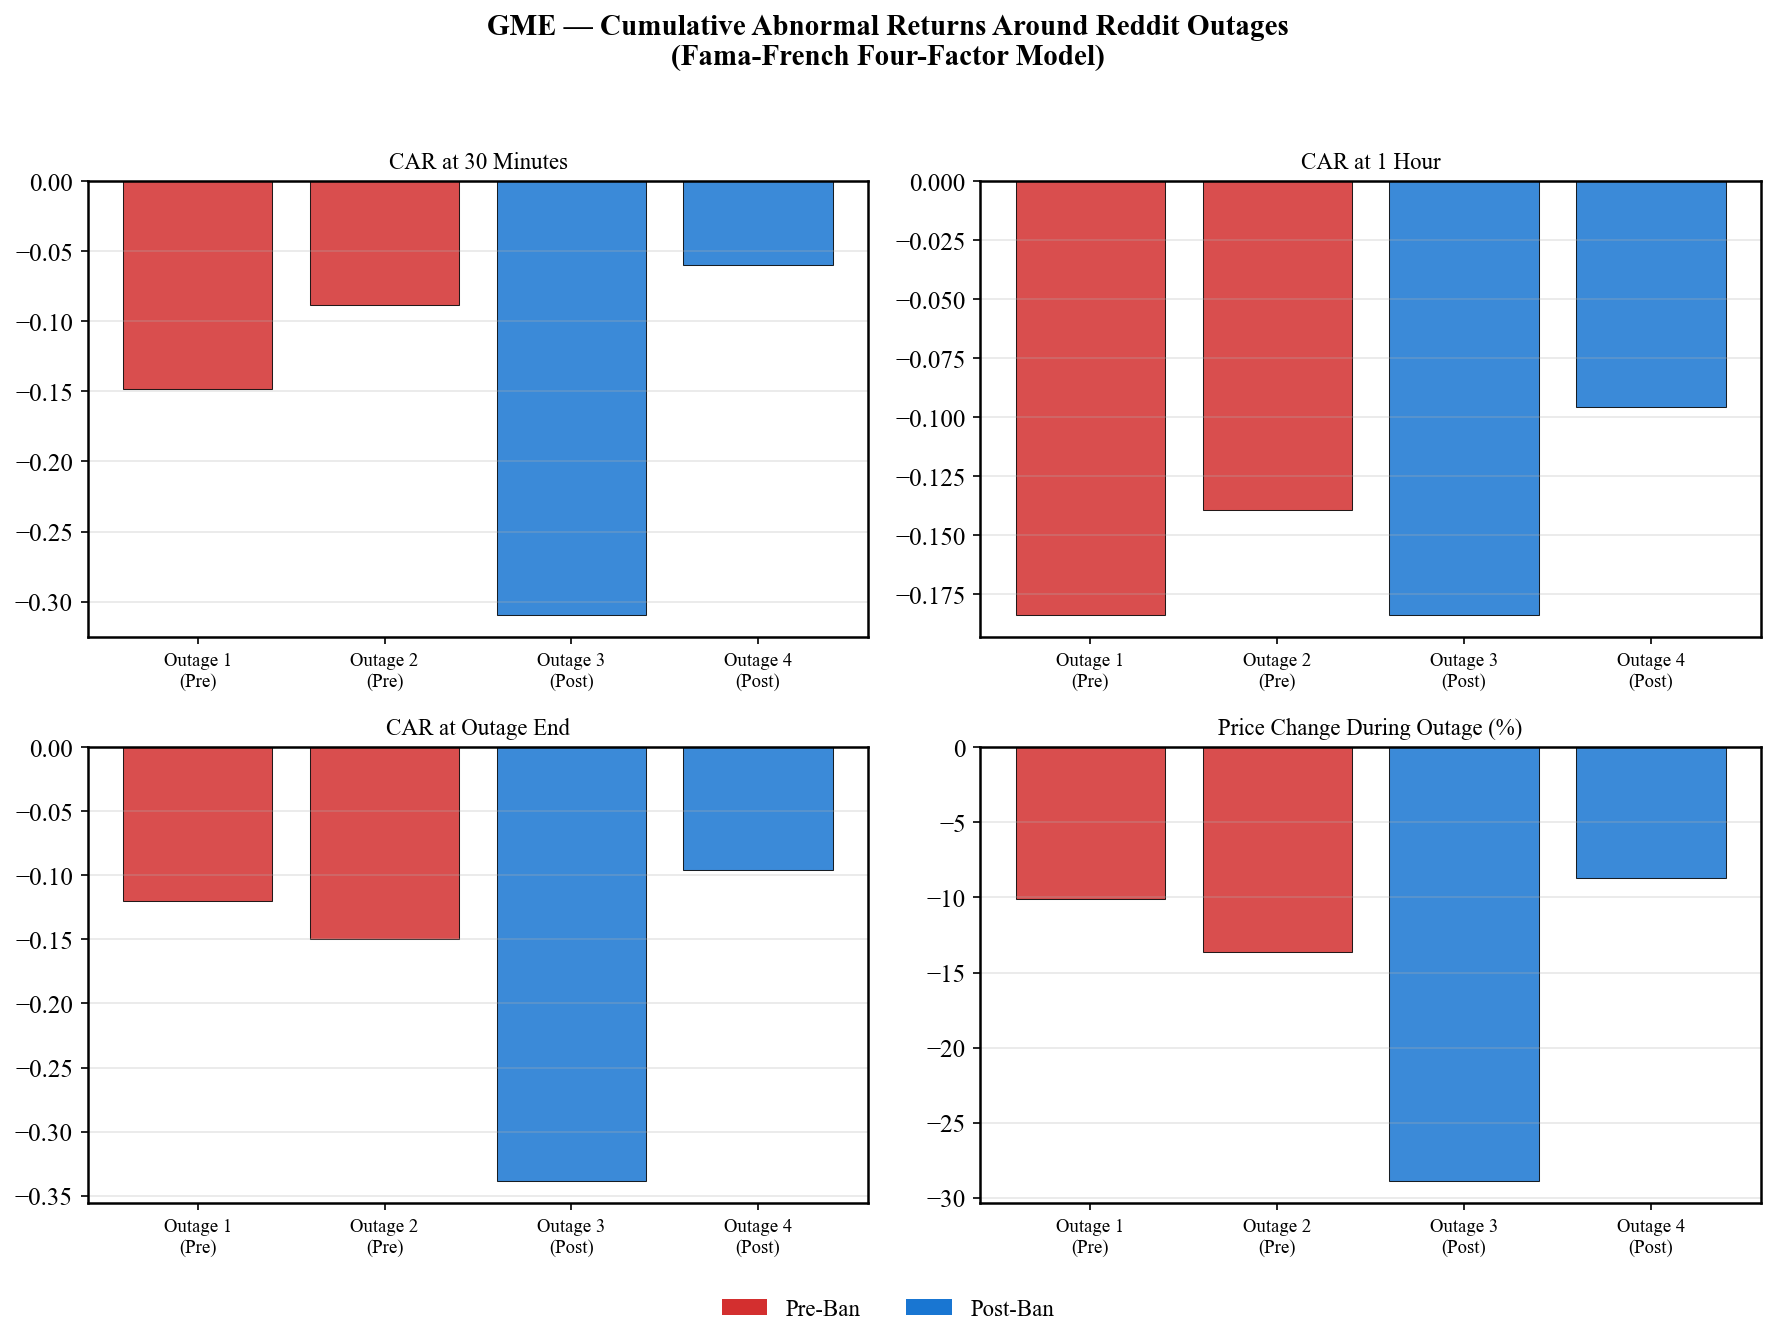

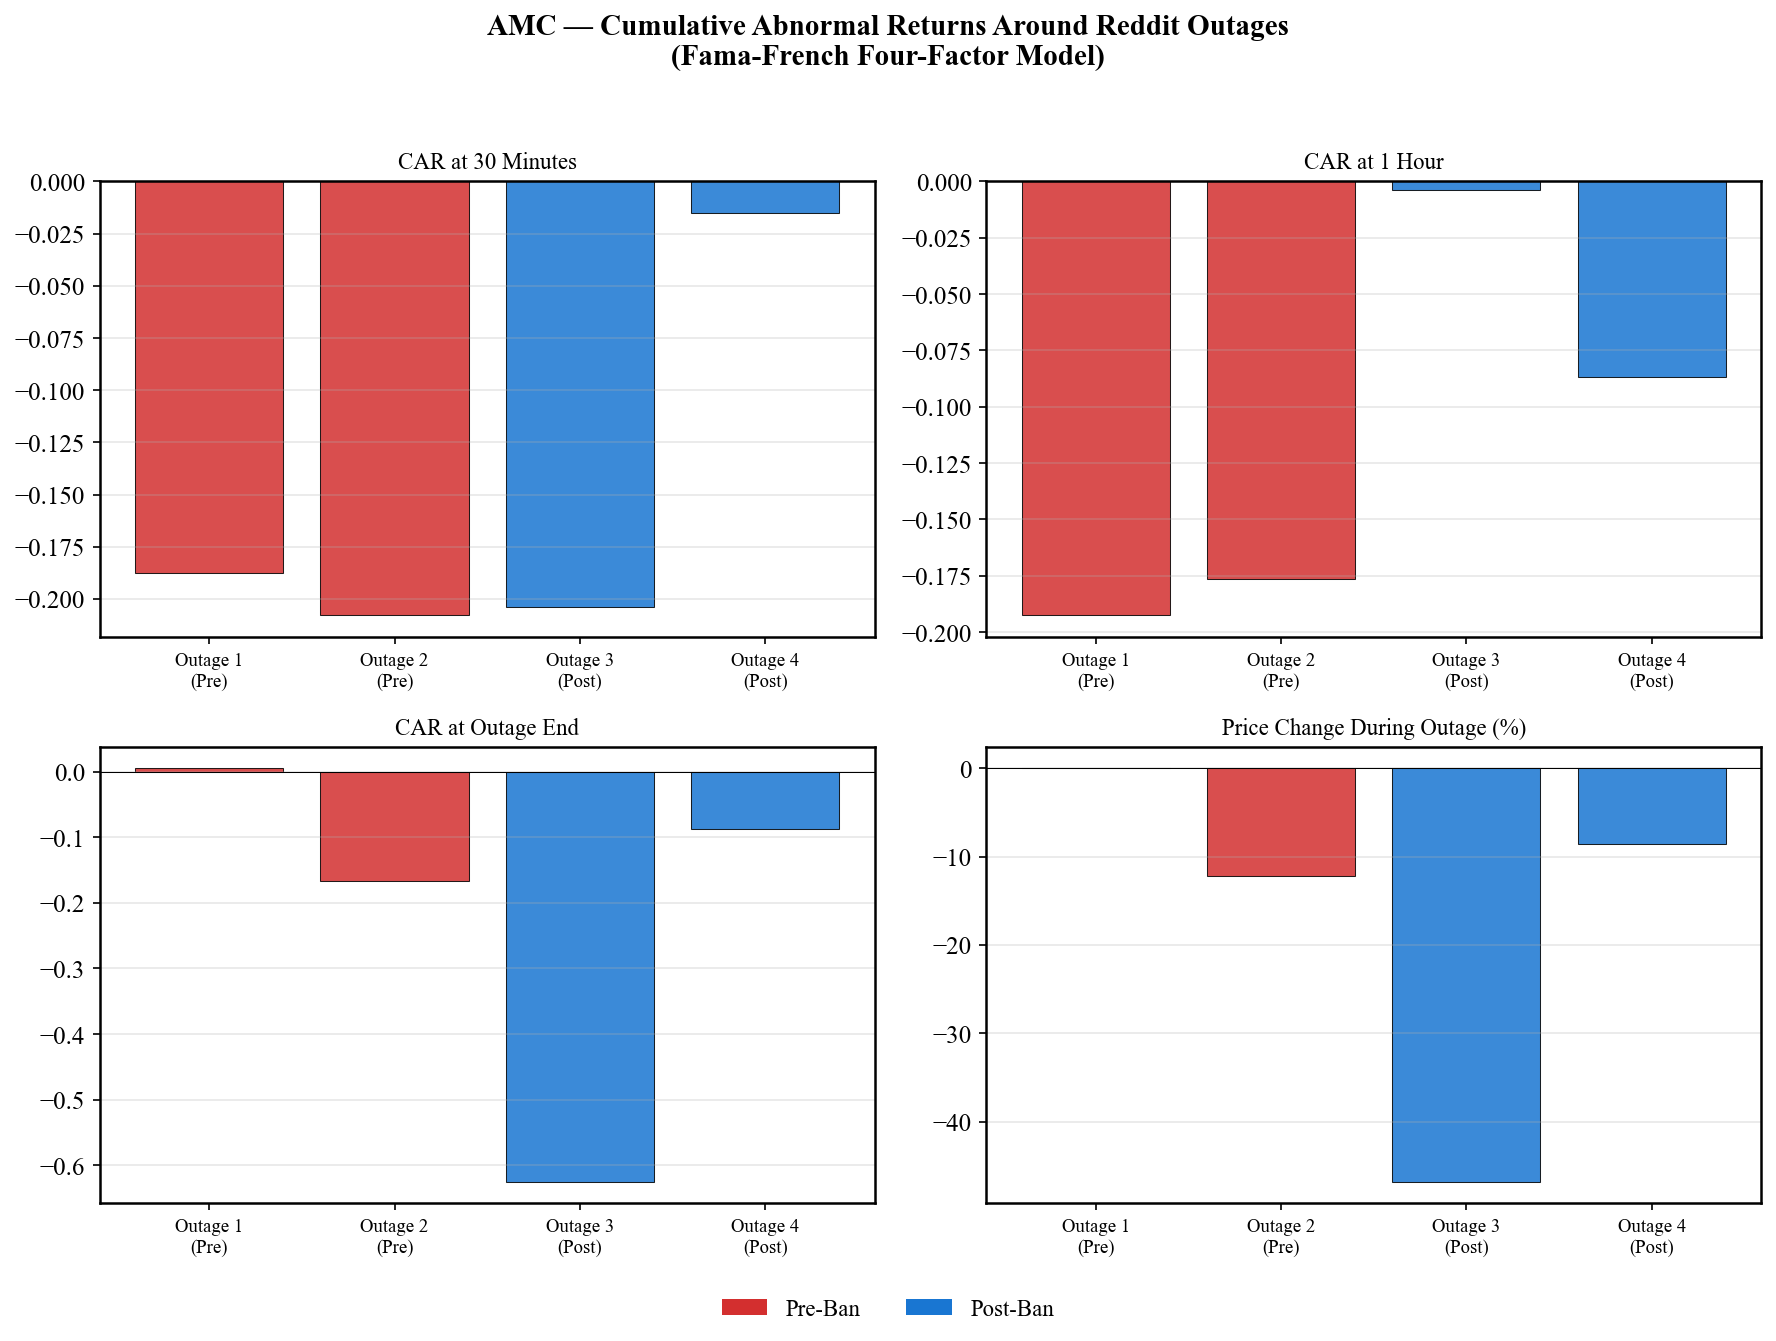

In [12]:
def plot_car_comparison(event_results, symbol):
    """2x2 bar chart: CAR at 30min, 1h, outage end, and price change."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(
        f"{symbol} — Cumulative Abnormal Returns Around Reddit Outages\n"
        f"(Fama-French Four-Factor Model)",
        fontsize=14, fontweight="bold"
    )

    metrics = [
        ("CAR_30min",         "CAR at 30 Minutes"),
        ("CAR_1h",            "CAR at 1 Hour"),
        ("CAR_at_outage_end", "CAR at Outage End"),
        ("price_change_pct",  "Price Change During Outage (%)"),
    ]

    for ax, (key, title) in zip(axes.flat, metrics):
        names  = [r["event_name"] for r in event_results]
        values = [r[key] for r in event_results]
        colors = [PRE_BAN_COLOR if r["pre_ban"] else POST_BAN_COLOR
                  for r in event_results]

        ax.bar(range(len(names)), values, color=colors, alpha=0.85,
               edgecolor="black", linewidth=0.5)

        ax.set_title(title, fontsize=11)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(
            [n.replace(" (Pre-Ban)", "\n(Pre)").replace(" (Post-Ban)", "\n(Post)")
             for n in names],
            fontsize=9
        )
        ax.axhline(0, color="black", linewidth=0.5)
        ax.grid(axis="y", alpha=0.3)

    legend_elements = [
        Patch(facecolor=PRE_BAN_COLOR,  label="Pre-Ban"),
        Patch(facecolor=POST_BAN_COLOR, label="Post-Ban"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=2,
               fontsize=11, frameon=False)

    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    fig.savefig(FIGURES_DIR / symbol.lower() / "car_comparison_ff4.png")
    plt.show()


for symbol in ["GME", "AMC"]:
    plot_car_comparison(all_results[symbol], symbol)

### 8b. Detailed Per-Event Plots

For each outage event: top panel shows stock price path; bottom panel shows the CAR trajectory
with the outage window shaded. After-hours events (Outages 2 and 4) may show flat CAR segments
where FF factors are unavailable.


======================================== GME ========================================


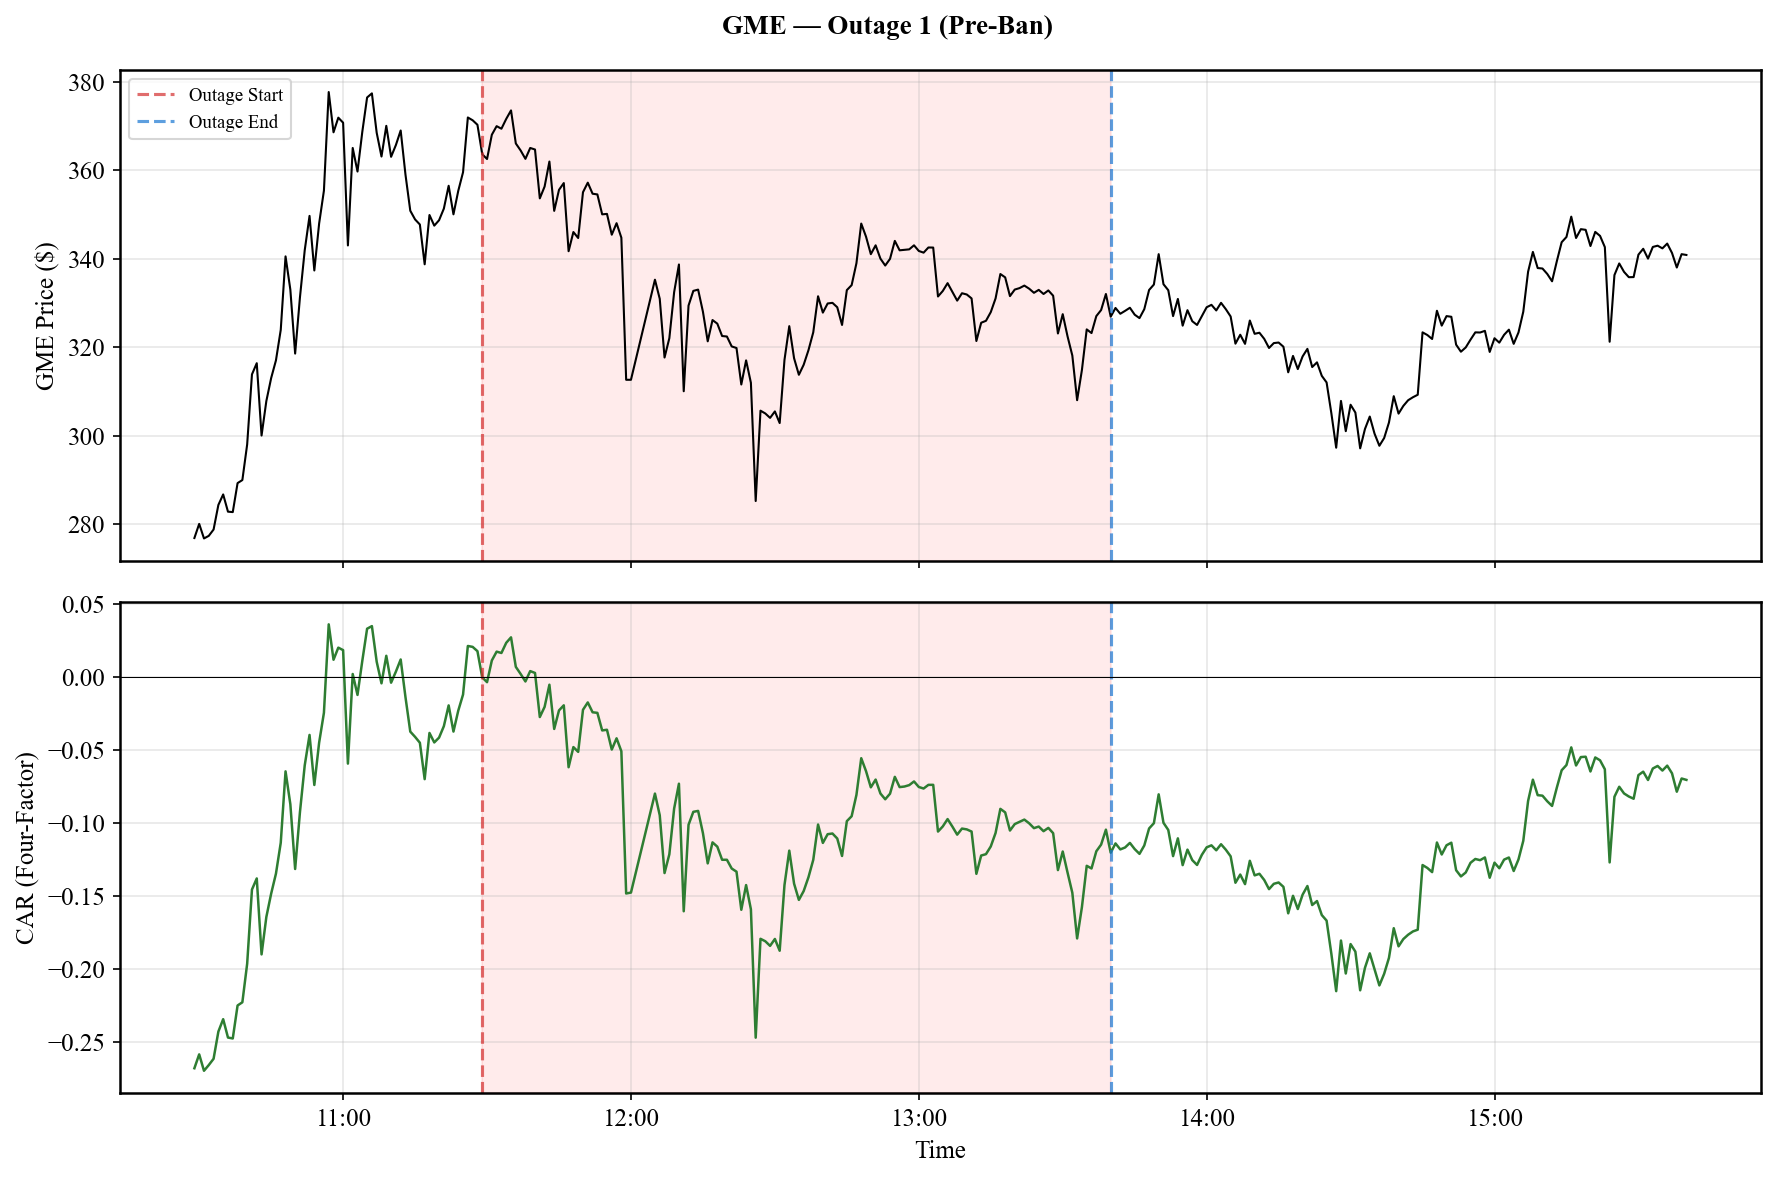

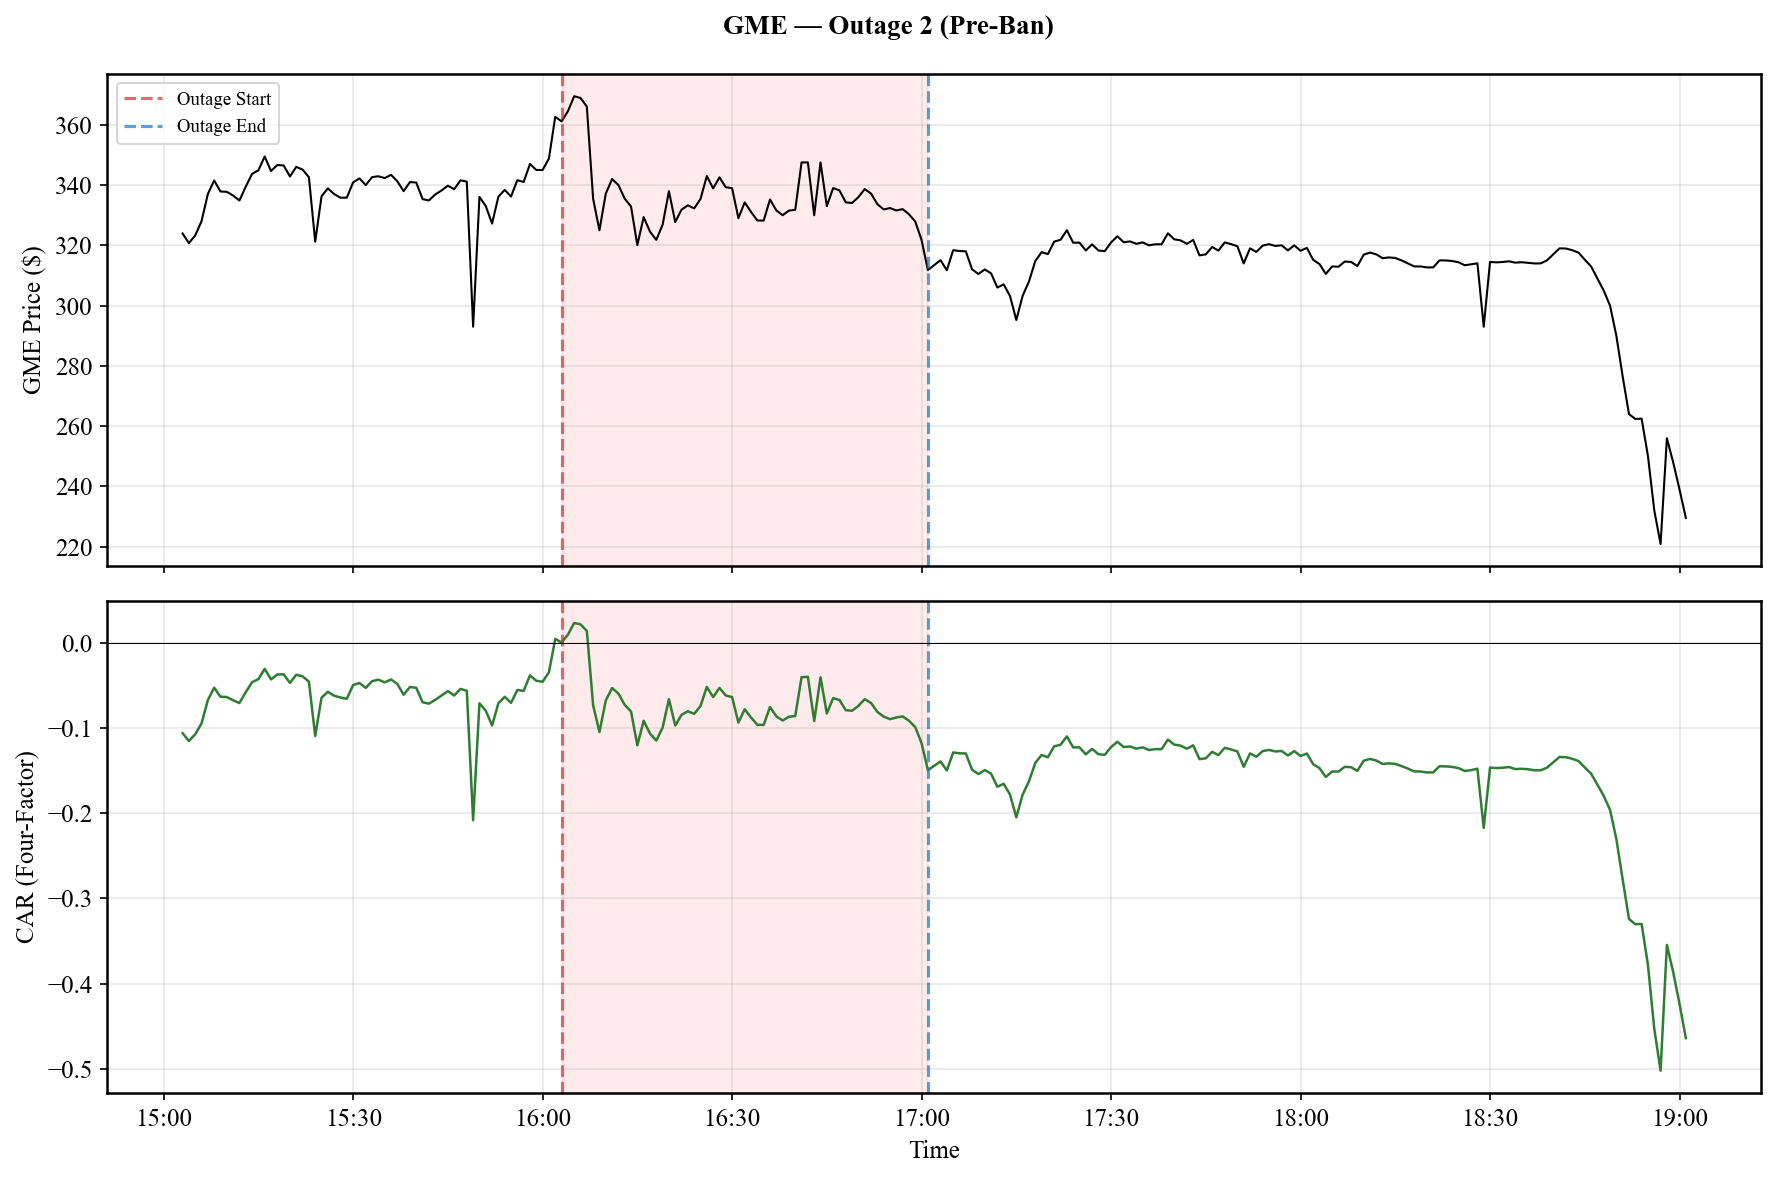

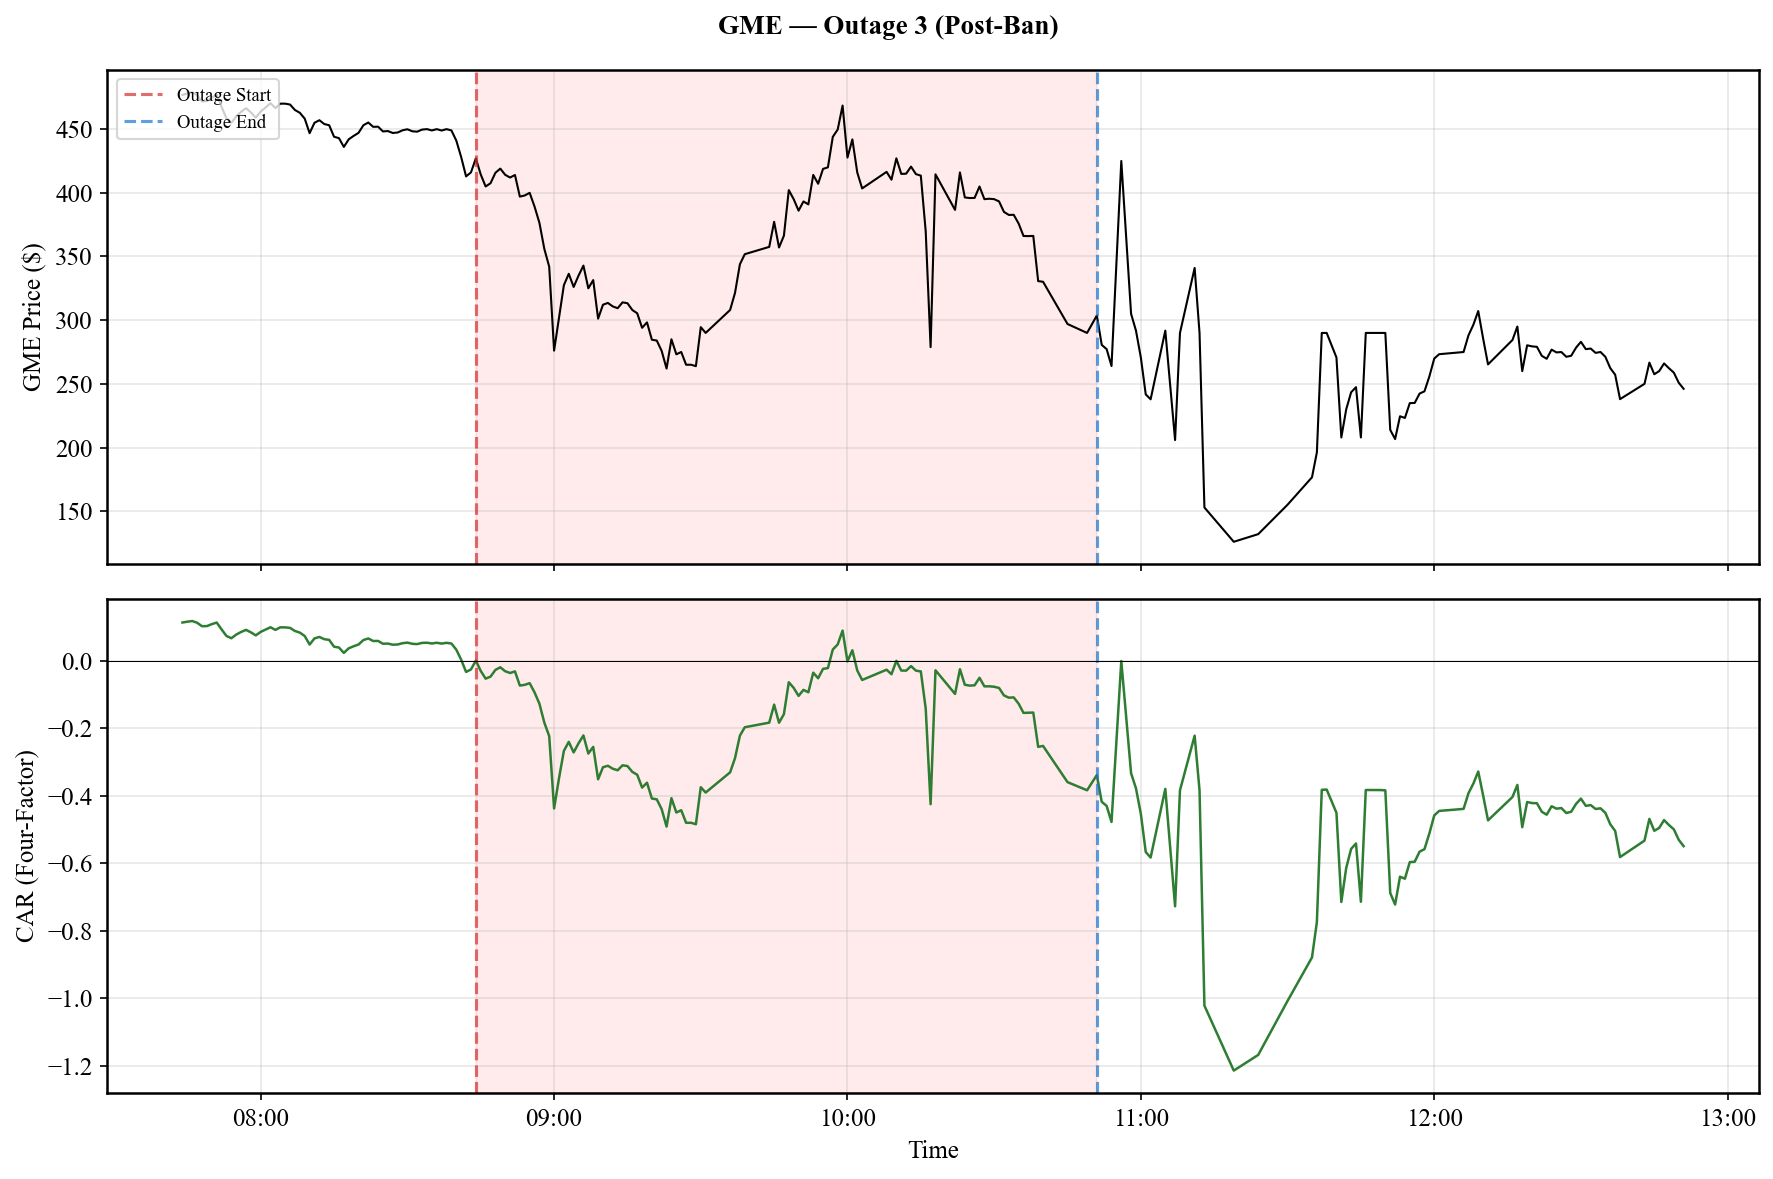

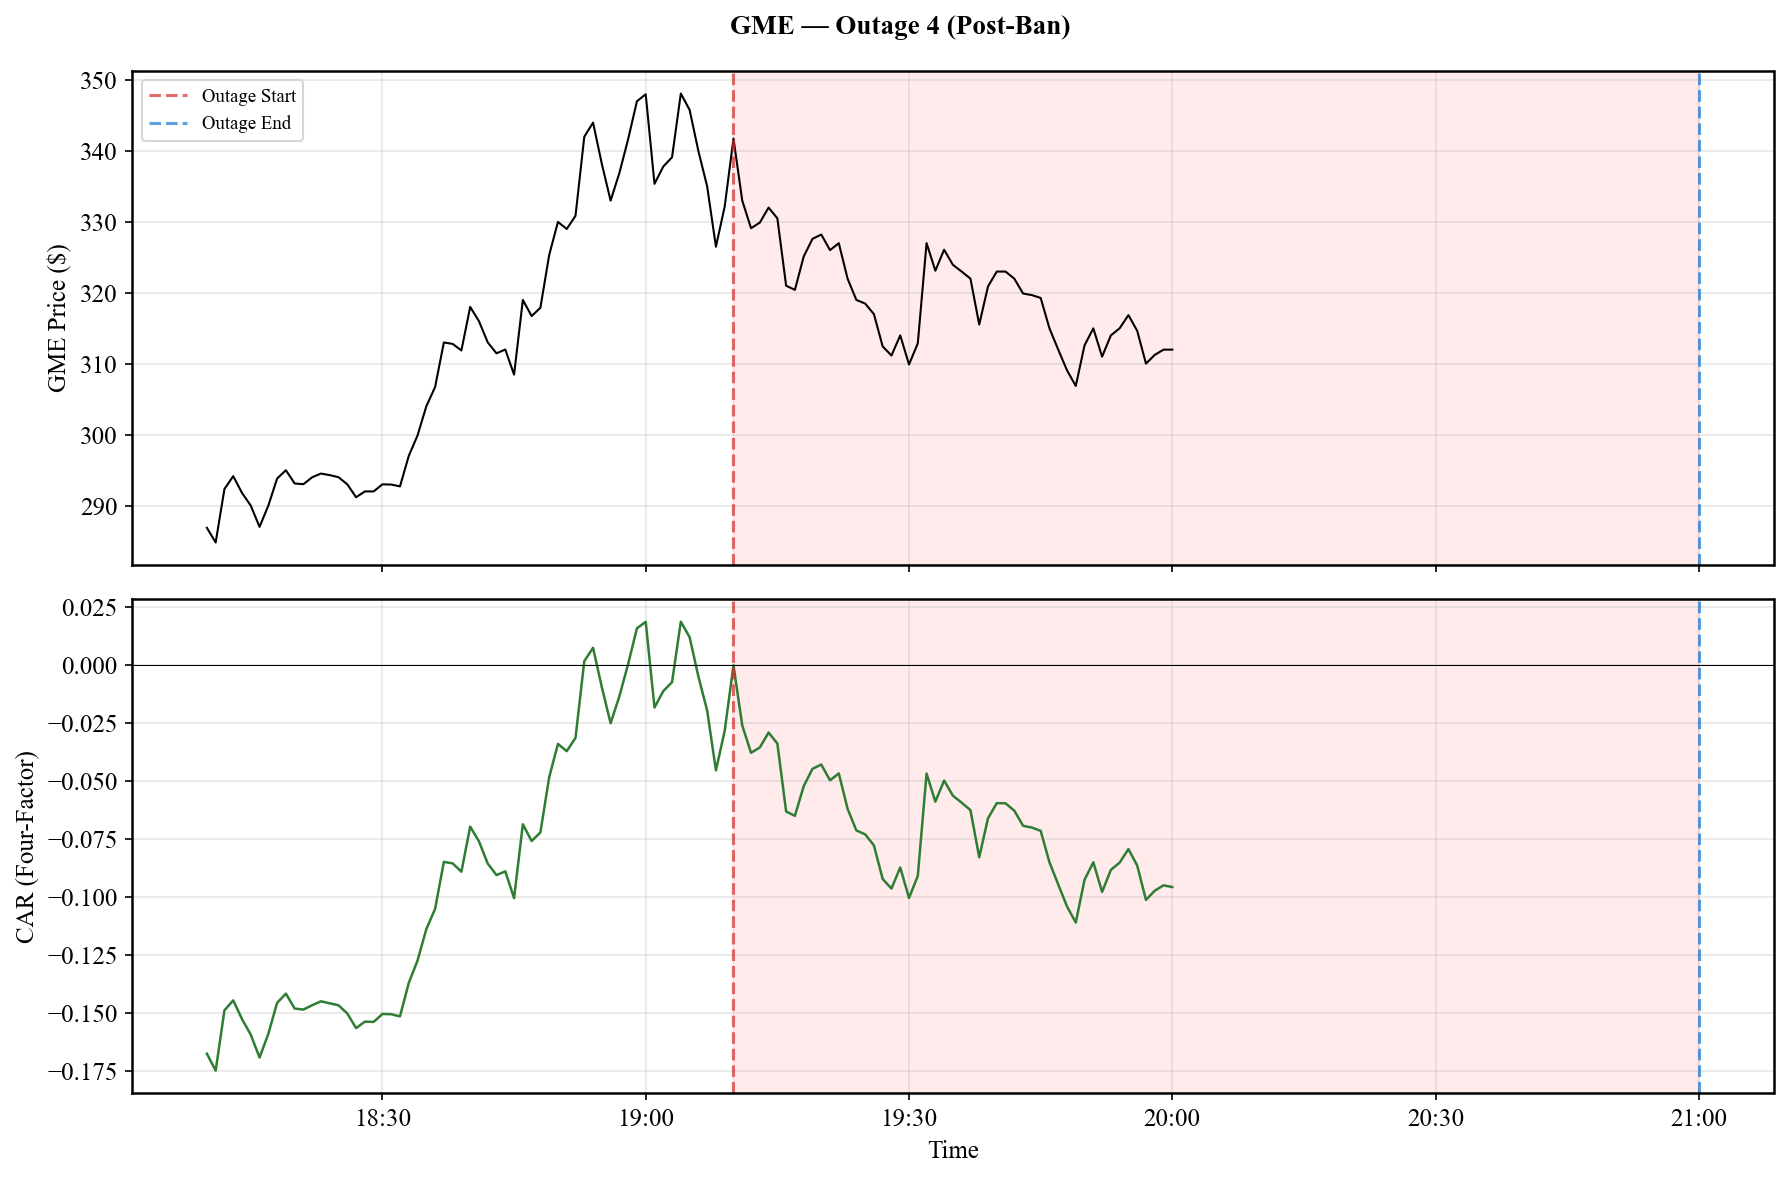


======================================== AMC ========================================


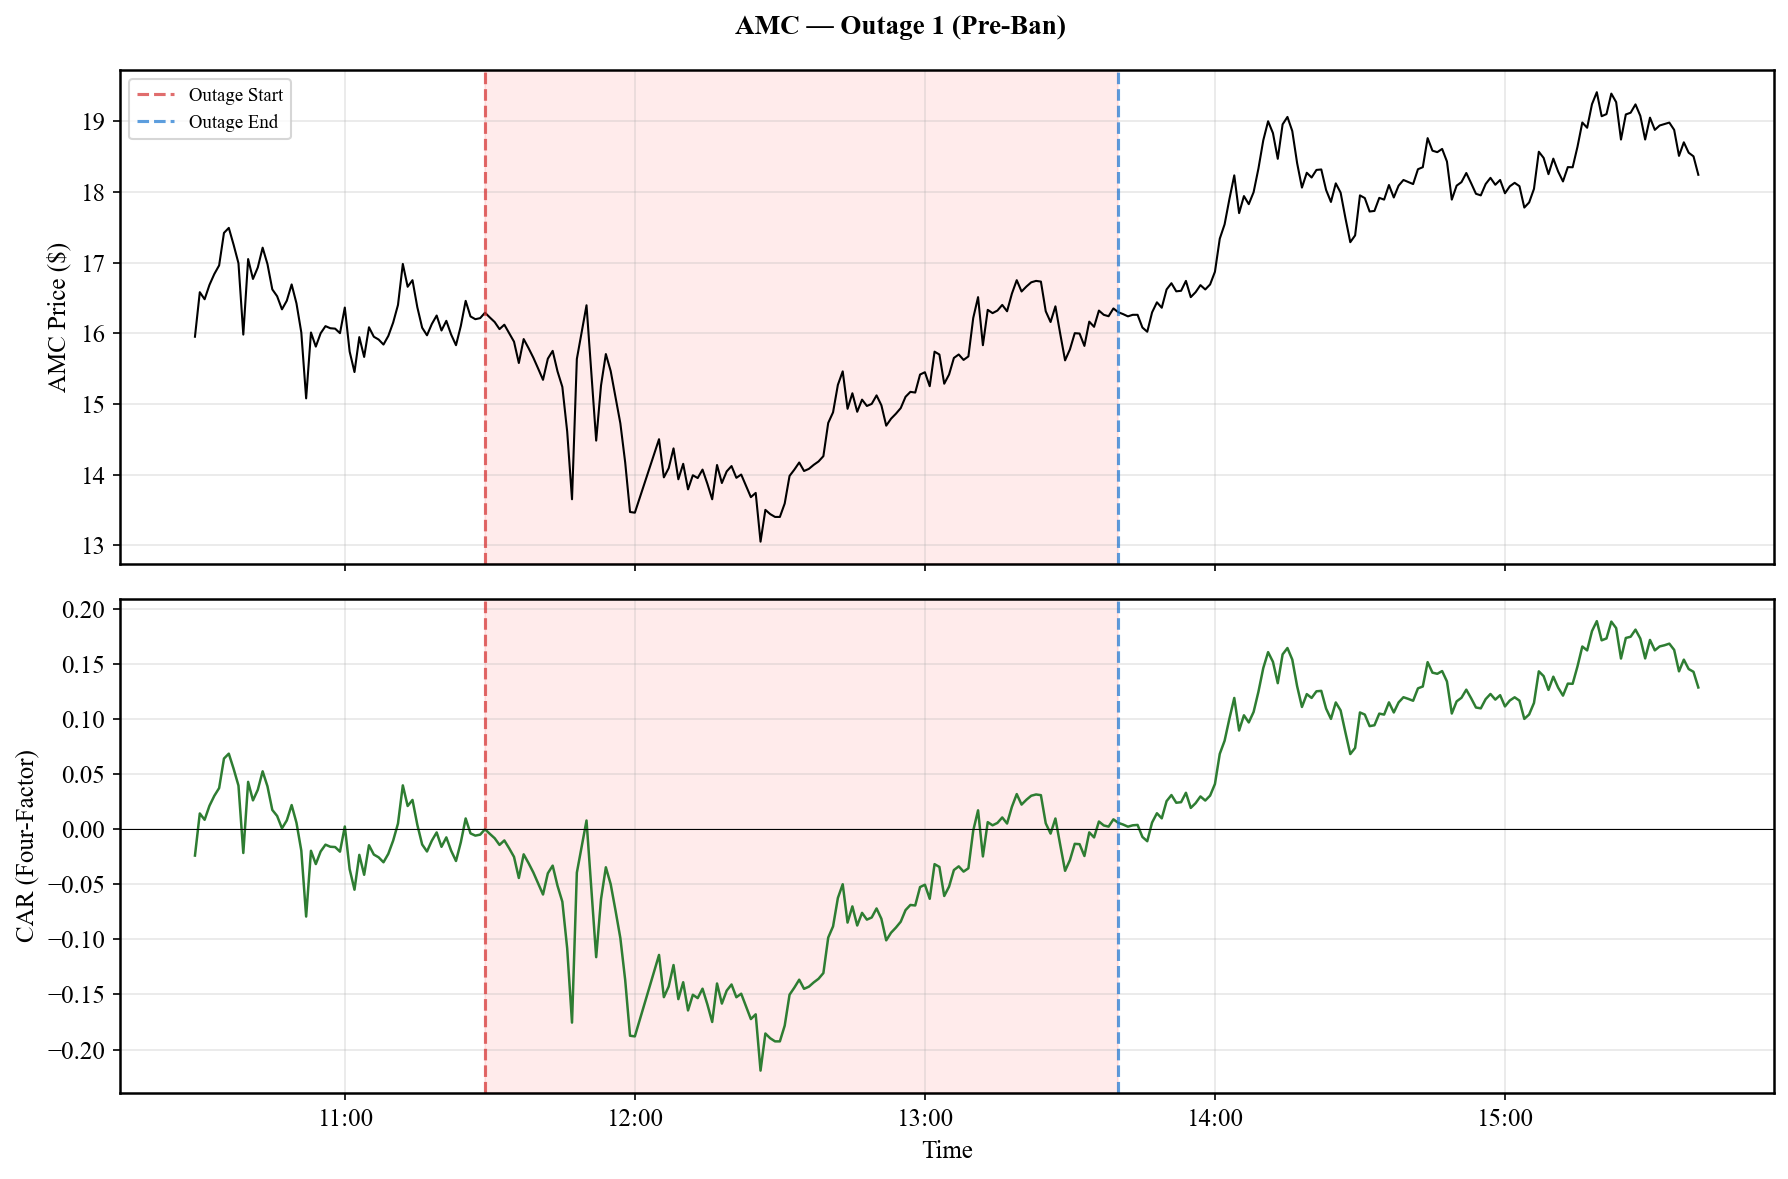

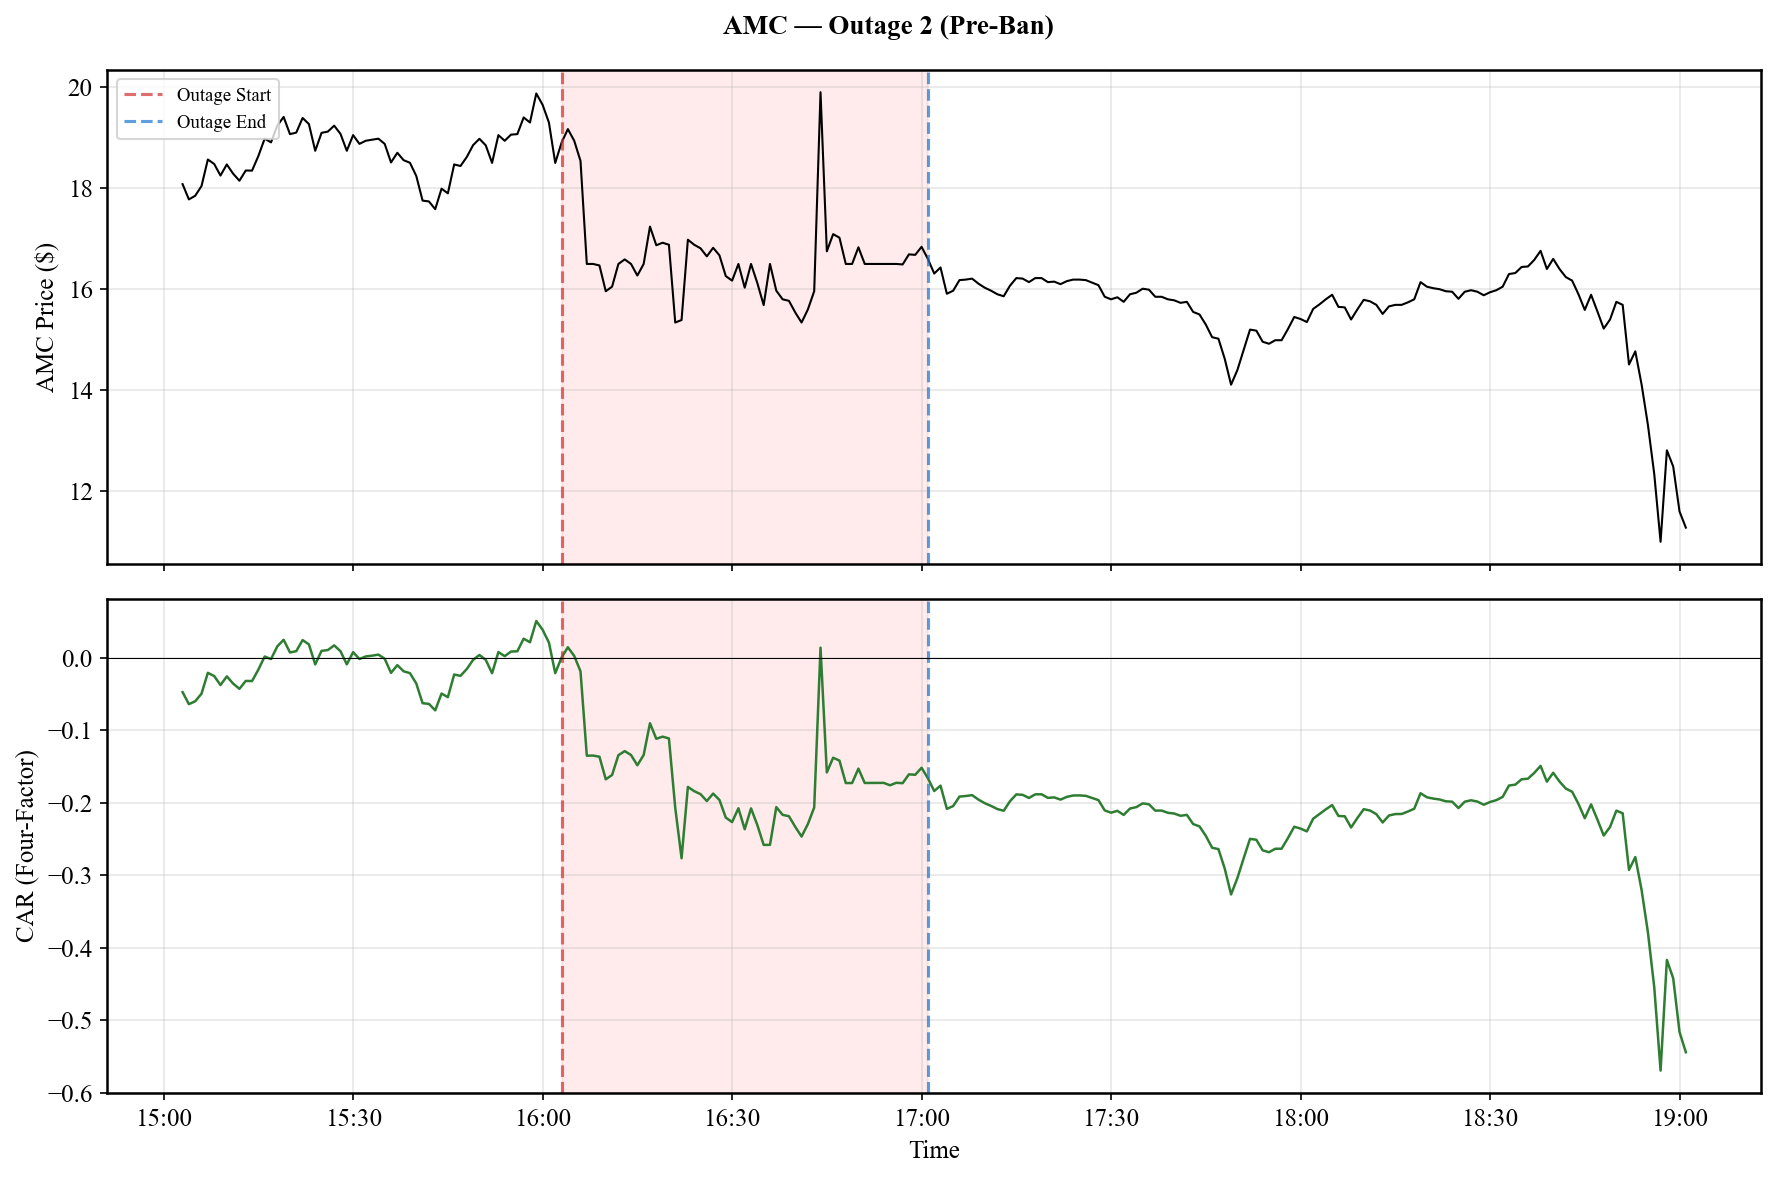

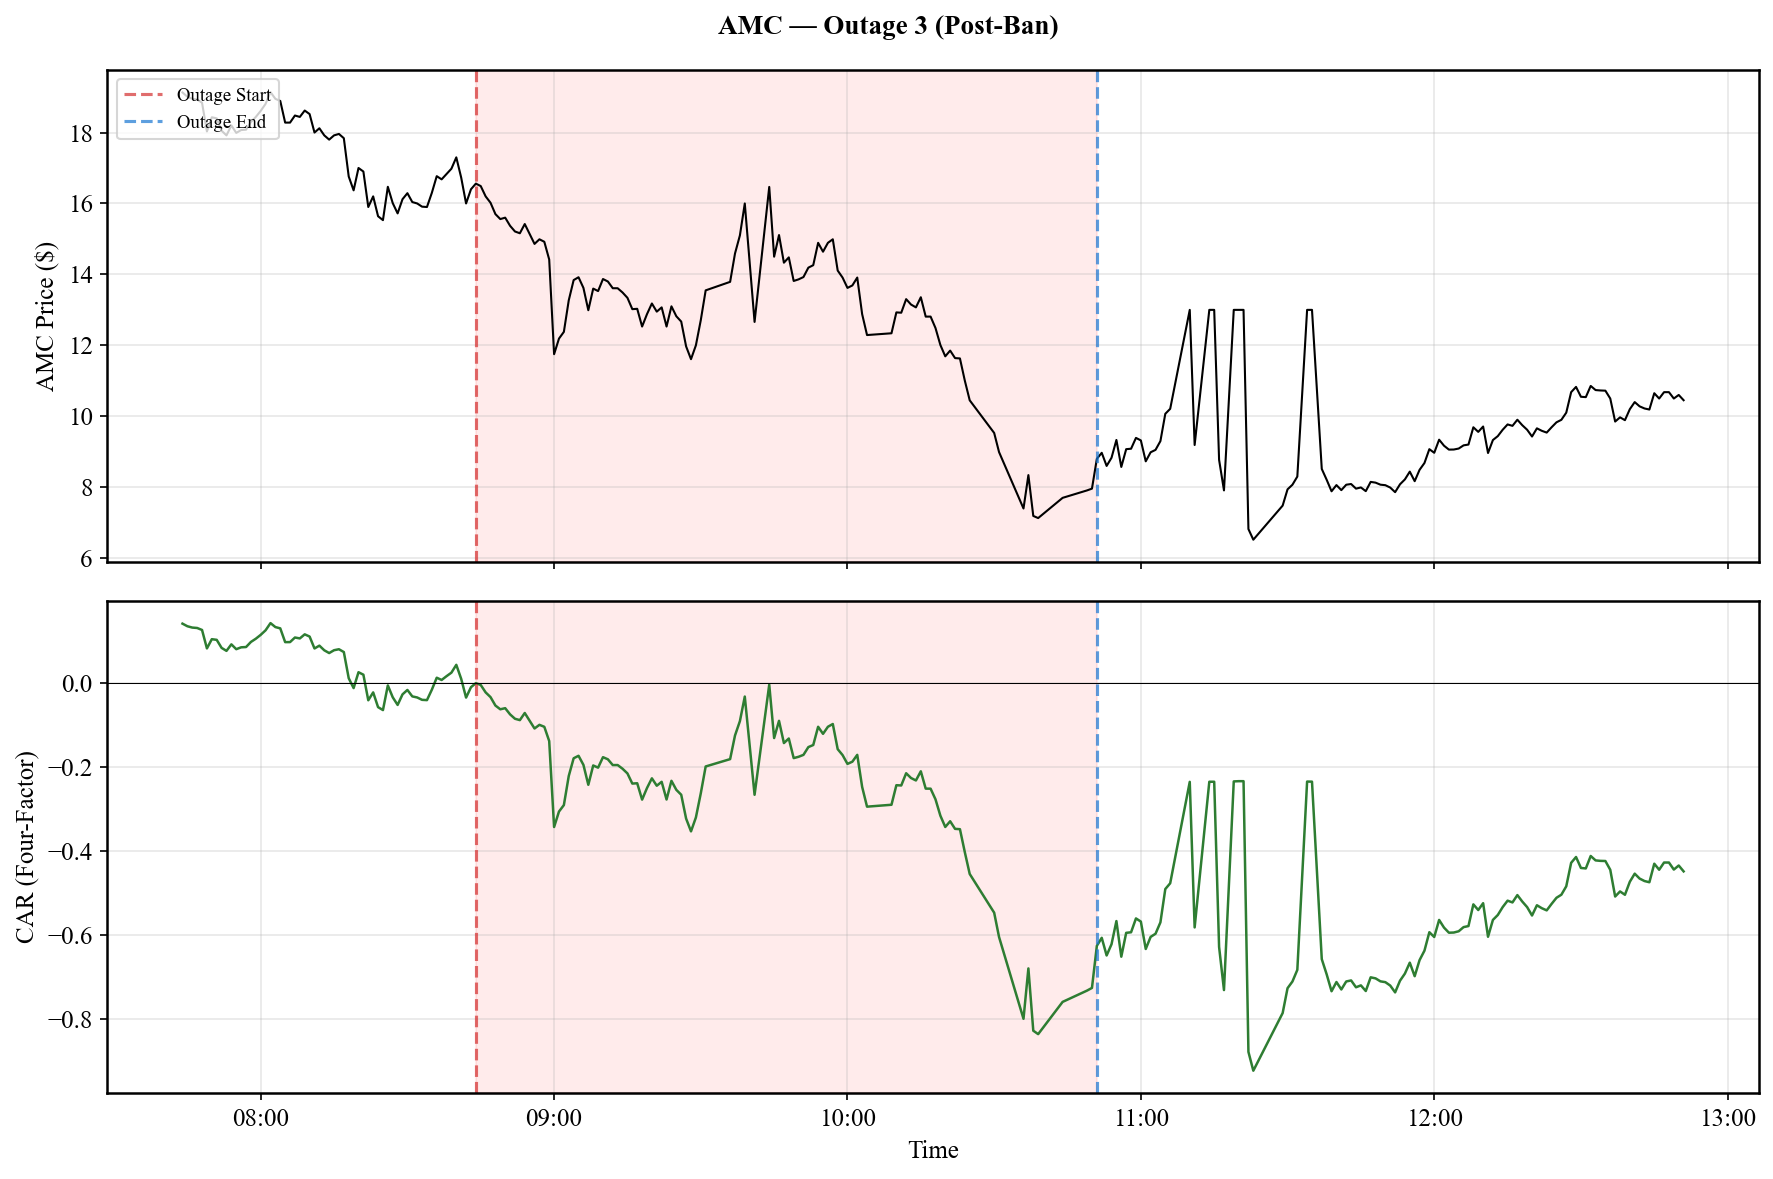

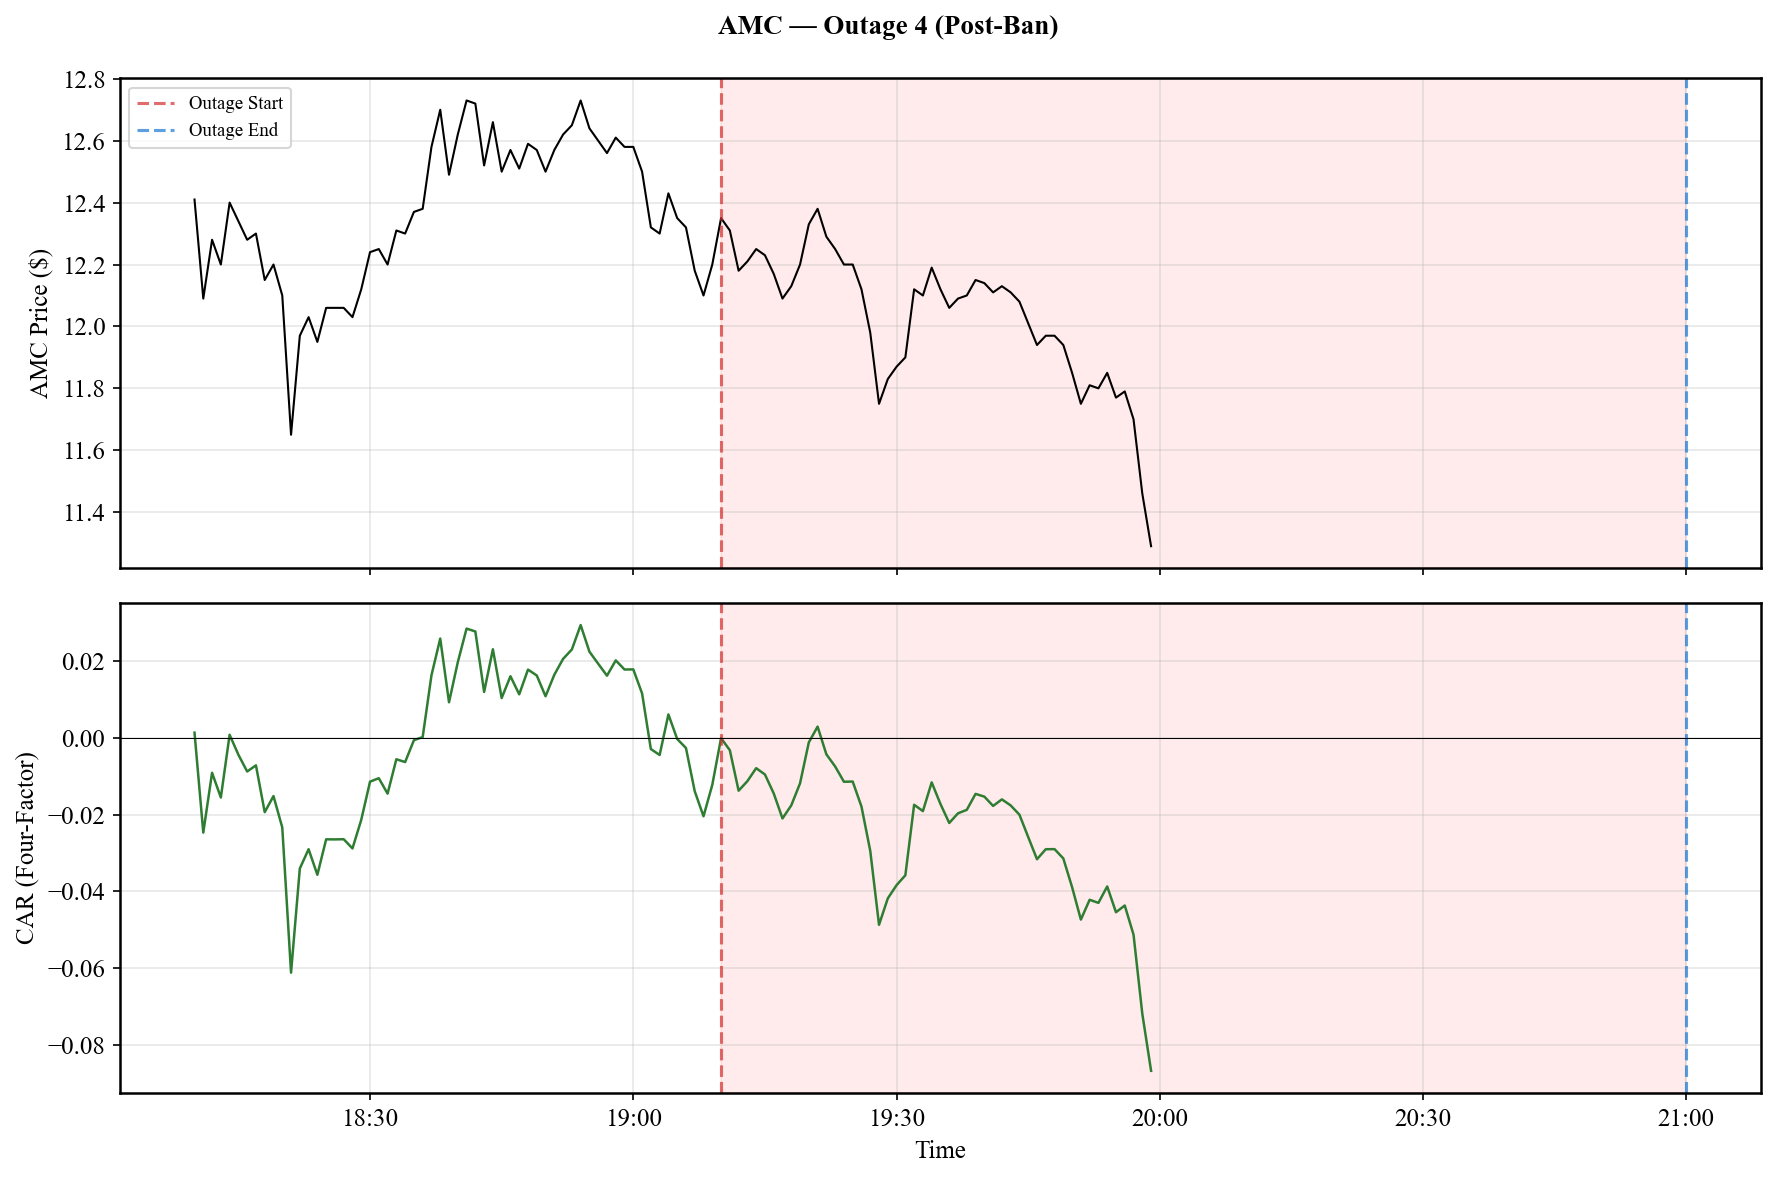

In [13]:
def plot_event_detail(result, symbol, event_num):
    """Two-panel figure: stock price + CAR path for a single outage event.
    Includes a 1-hour pre-period to the left of the outage window so that
    pre-trends are visible. CAR is normalized to 0 at outage start."""
    ed = result["event_data"]
    if ed.empty:
        return

    price_col   = STOCKS[symbol]["price_col"]
    event_start = result["start_time"]
    event_end   = result["end_time"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(f"{symbol} — {result['event_name']}", fontsize=13,
                 fontweight="bold")

    # Top: price
    ax1.plot(ed.index, ed[price_col], color="black", linewidth=1.0)
    ax1.axvline(event_start, color=PRE_BAN_COLOR,  linestyle="--",
                alpha=0.7, label="Outage Start")
    ax1.axvline(event_end,   color=POST_BAN_COLOR, linestyle="--",
                alpha=0.7, label="Outage End")
    ax1.axvspan(event_start, event_end, alpha=0.08, color="red")
    ax1.set_ylabel(f"{symbol} Price ($)")
    ax1.legend(loc="upper left", fontsize=9)
    ax1.grid(alpha=0.3)

    # Bottom: CAR (normalized to 0 at event_start; pre-period shows pre-trend)
    ax2.plot(ed.index, ed["CAR"], color="#2E7D32", linewidth=1.2)
    ax2.axvline(event_start, color=PRE_BAN_COLOR,  linestyle="--", alpha=0.7)
    ax2.axvline(event_end,   color=POST_BAN_COLOR, linestyle="--", alpha=0.7)
    ax2.axvspan(event_start, event_end, alpha=0.08, color="red")
    ax2.axhline(0, color="black", linewidth=0.5)
    ax2.set_ylabel("CAR (Four-Factor)")
    ax2.set_xlabel("Time")
    ax2.grid(alpha=0.3)

    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    plt.tight_layout()

    tag = (result["event_name"].lower()
           .replace(" ", "_").replace("(", "").replace(")", ""))
    fig.savefig(FIGURES_DIR / symbol.lower() / f"event_{event_num}_{tag}.png")
    plt.show()


for symbol in ["GME", "AMC"]:
    print(f"\n{'='*40} {symbol} {'='*40}")
    for i, r in enumerate(all_results[symbol], 1):
        plot_event_detail(r, symbol, i)


### 8c. Pre-Ban vs Post-Ban Summary (Both Stocks)

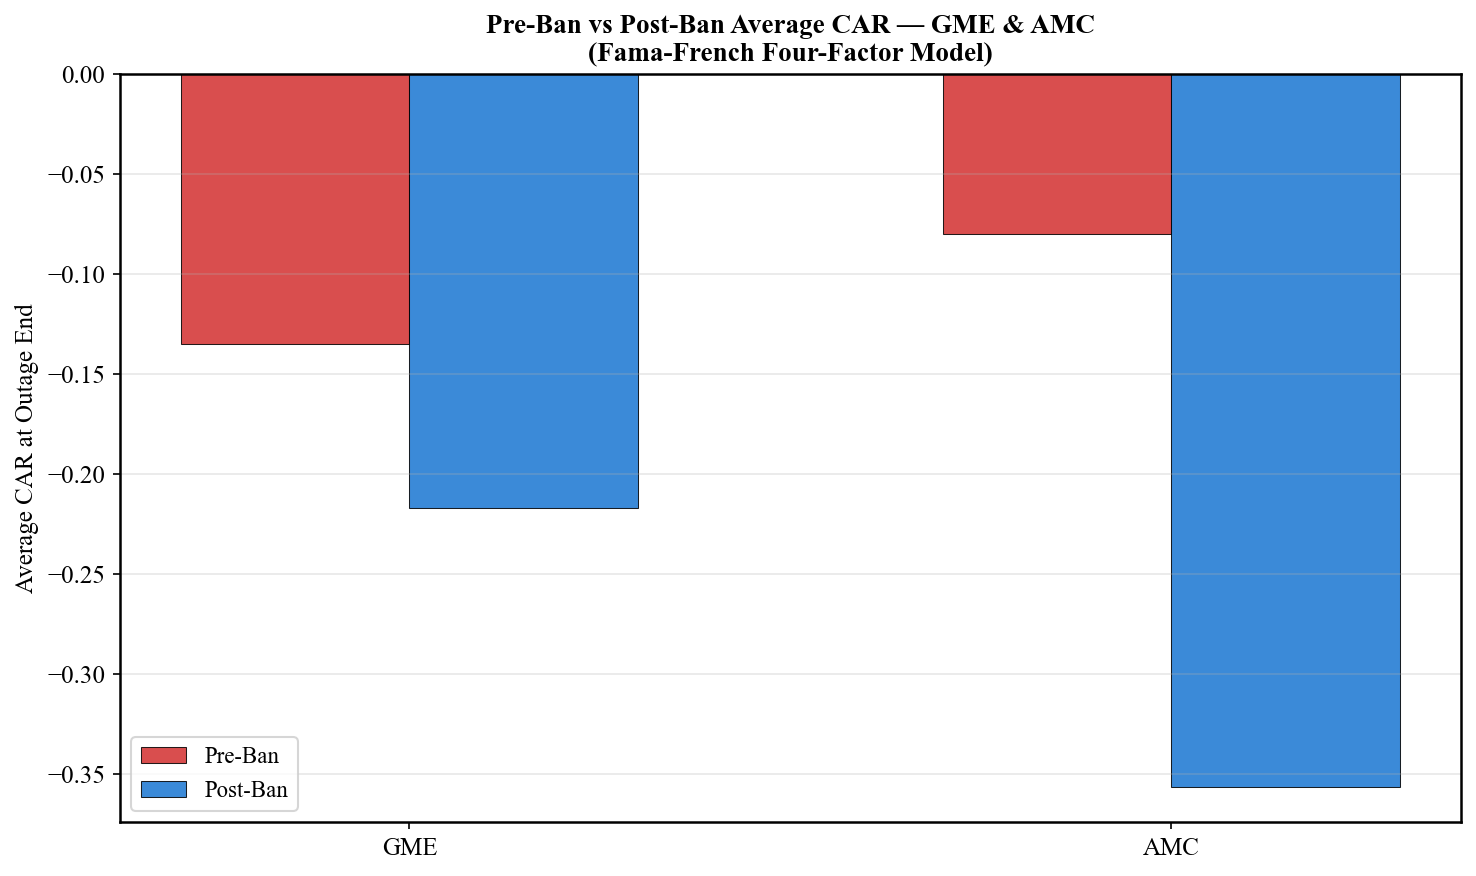

In [14]:
def plot_pre_vs_post_ban_summary(all_results):
    """Grouped bar chart comparing GME and AMC average CARs, pre-ban vs post-ban."""
    fig, ax = plt.subplots(figsize=(10, 6))

    symbols = list(all_results.keys())
    x       = np.arange(len(symbols))
    width   = 0.3

    for i, label, color in [
        (0, "Pre-Ban",  PRE_BAN_COLOR),
        (1, "Post-Ban", POST_BAN_COLOR),
    ]:
        means = []
        for sym in symbols:
            cars = [r["CAR_at_outage_end"] for r in all_results[sym]
                    if r["pre_ban"] == (label == "Pre-Ban")]
            means.append(np.mean(cars) if cars else 0)
        ax.bar(x + i * width - width / 2, means, width, label=label,
               color=color, alpha=0.85, edgecolor="black", linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(symbols, fontsize=12)
    ax.set_ylabel("Average CAR at Outage End")
    ax.set_title(
        "Pre-Ban vs Post-Ban Average CAR — GME & AMC\n(Fama-French Four-Factor Model)",
        fontsize=13, fontweight="bold"
    )
    ax.axhline(0, color="black", linewidth=0.5)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "pre_vs_post_ban_summary_ff4.png")
    plt.show()


plot_pre_vs_post_ban_summary(all_results)

---
## 9. Summary of Findings

In [15]:
print("=" * 72)
print("  SUMMARY: Reddit Outage Impact on Meme Stock Returns")
print("  (Fama-French Four-Factor Model — after-hours uses market-model fallback)")
print("=" * 72)

for symbol in ["GME", "AMC"]:
    results   = all_results[symbol]
    pre_cars  = [r["CAR_at_outage_end"] for r in results if r["pre_ban"]]
    post_cars = [r["CAR_at_outage_end"] for r in results if not r["pre_ban"]]

    print(f"\n--- {symbol} ---")
    print(f"  Pre-ban avg CAR:   {np.mean(pre_cars):+.4f}")
    print(f"  Post-ban avg CAR:  {np.mean(post_cars):+.4f}")
    print(f"  Difference:        {np.mean(post_cars) - np.mean(pre_cars):+.4f}")

    print(f"\n  Event-level detail:")
    for r in results:
        period   = "Pre-Ban " if r["pre_ban"] else "Post-Ban"
        ff_note  = f"  [FF: {r['n_ff_minutes']}/{r['n_total_minutes']} mins]"
        print(f"    [{period}] {r['event_name']:<28}  "
              f"CAR = {r['CAR_at_outage_end']:+.4f}   "
              f"Price Chg = {r['price_change_pct']:+.2f}%"
              f"{ff_note}")

print(f"\nAll output files saved to: {OUTPUT_DIR}")
print(f"Figures saved to:          {FIGURES_DIR}")

  SUMMARY: Reddit Outage Impact on Meme Stock Returns
  (Fama-French Four-Factor Model — after-hours uses market-model fallback)

--- GME ---
  Pre-ban avg CAR:   -0.1349
  Post-ban avg CAR:  -0.2172
  Difference:        -0.0822

  Event-level detail:
    [Pre-Ban ] Outage 1 (Pre-Ban)            CAR = -0.1201   Price Chg = -10.10%  [FF: 128/128 mins]
    [Pre-Ban ] Outage 2 (Pre-Ban)            CAR = -0.1498   Price Chg = -13.66%  [FF: 0/59 mins]
    [Post-Ban] Outage 3 (Post-Ban)           CAR = -0.3387   Price Chg = -28.89%  [FF: 57/105 mins]
    [Post-Ban] Outage 4 (Post-Ban)           CAR = -0.0956   Price Chg = -8.71%  [FF: 0/51 mins]

--- AMC ---
  Pre-ban avg CAR:   -0.0803
  Post-ban avg CAR:  -0.3564
  Difference:        -0.2761

  Event-level detail:
    [Pre-Ban ] Outage 1 (Pre-Ban)            CAR = +0.0058   Price Chg = +0.04%  [FF: 126/126 mins]
    [Pre-Ban ] Outage 2 (Pre-Ban)            CAR = -0.1664   Price Chg = -12.17%  [FF: 0/59 mins]
    [Post-Ban] Outage 3 (Post-B

---
## 10. Recovery Analysis: Post-Outage CAR

Once each Reddit outage **ended**, did prices recover? This section computes CARs anchored
at outage end (CAR = 0 at `outage_end`) and accumulated forward over a 2-hour recovery window.

We report CARs at **+30 min**, **+1 hr**, and **+2 hr** after each outage ends, along with
Patell t-statistics at each horizon:

$$t_k = \frac{CAR_{+k}}{\hat{\sigma}_{\varepsilon} \cdot \sqrt{N_k}}$$

where $N_k$ is the number of minutes in the recovery window up to horizon $k$, and
$\hat{\sigma}_{\varepsilon}$ is the residual std from the same FF4 estimation window.

The same FF4 model (with SPY fallback for after-hours) is used throughout.

In [16]:
from scipy import stats as scipy_stats


def calculate_recovery_car(stock_data, ff_data, event, model_params, symbol,
                           recovery_window_hours=2):
    """
    Calculate CAR for the recovery period after an outage ends.
    CAR is anchored to 0 at outage_end and accumulated forward.
    Reports CARs at +30min, +1hr, and +2hr with Patell t-stats at each horizon.

    Uses the same FF4 model with SPY fallback for after-hours minutes.
    """
    recovery_start = event["end"]
    recovery_end   = recovery_start + timedelta(hours=recovery_window_hours)

    event_data = stock_data.loc[recovery_start:recovery_end].copy()
    if event_data.empty:
        return None

    return_col = STOCKS[symbol]["return_col"]
    price_col  = STOCKS[symbol]["price_col"]

    # Left-join FF factors; apply SPY fallback for after-hours minutes
    event_data = event_data.join(ff_data[["MKT_RF", "SMB", "HML", "MOM"]], how="left")
    factor_missing = event_data["MKT_RF"].isna()
    if factor_missing.any():
        event_data.loc[factor_missing, "MKT_RF"] = event_data.loc[factor_missing, "spy_return"]
        event_data.loc[factor_missing, "SMB"]    = 0.0
        event_data.loc[factor_missing, "HML"]    = 0.0
        event_data.loc[factor_missing, "MOM"]    = 0.0

    alpha    = model_params["alpha"]
    beta_mkt = model_params["beta_mkt"]
    beta_smb = model_params["beta_smb"]
    beta_hml = model_params["beta_hml"]
    beta_mom = model_params["beta_mom"]
    sigma    = model_params["residual_std"]

    event_data["expected_return"] = (
        alpha
        + beta_mkt * event_data["MKT_RF"]
        + beta_smb * event_data["SMB"]
        + beta_hml * event_data["HML"]
        + beta_mom * event_data["MOM"]
    )
    event_data["ff_factors_available"] = ~factor_missing
    event_data["AR"]  = event_data[return_col] - event_data["expected_return"]
    event_data["CAR"] = event_data["AR"].cumsum()

    def car_at(target):
        mask = event_data.index <= target
        return event_data.loc[mask, "CAR"].iloc[-1] if mask.any() else np.nan

    def t_at(car_val, n):
        if sigma > 0 and n > 0 and not np.isnan(car_val):
            t = car_val / (sigma * np.sqrt(n))
            p = 2 * (1 - scipy_stats.norm.cdf(abs(t)))
            return t, p
        return np.nan, np.nan

    car_30m = car_at(recovery_start + timedelta(minutes=30))
    car_1h  = car_at(recovery_start + timedelta(hours=1))
    car_2h  = event_data["CAR"].iloc[-1] if len(event_data) else np.nan

    n_30 = len(event_data.loc[recovery_start : recovery_start + timedelta(minutes=30)])
    n_1h = len(event_data.loc[recovery_start : recovery_start + timedelta(hours=1)])
    n_2h = len(event_data)

    t30, p30 = t_at(car_30m, n_30)
    t1h, p1h = t_at(car_1h,  n_1h)
    t2h, p2h = t_at(car_2h,  n_2h)

    n_ff_mins = int(event_data["ff_factors_available"].sum())

    if len(event_data) >= 2:
        price_change_pct = ((event_data[price_col].iloc[-1] - event_data[price_col].iloc[0])
                            / event_data[price_col].iloc[0] * 100)
    else:
        price_change_pct = np.nan

    return {
        "event_name":                event["name"],
        "recovery_start":            recovery_start,
        "recovery_end":              recovery_end,
        "duration_minutes":          event["duration_minutes"],
        "pre_ban":                   event["pre_ban"],
        "CAR_30min_recovery":        car_30m,
        "CAR_1h_recovery":           car_1h,
        "CAR_2h_recovery":           car_2h,
        "t_stat_30":  t30, "p_value_30":  p30,
        "t_stat_1h":  t1h, "p_value_1h":  p1h,
        "t_stat_2h":  t2h, "p_value_2h":  p2h,
        "price_change_recovery_pct": price_change_pct,
        "n_ff_minutes":              n_ff_mins,
        "n_total_minutes":           n_2h,
        "event_data":                event_data,
    }

In [17]:
# Run recovery analysis for both stocks
recovery_results = {}

for symbol, data, params in [
    ("GME", gme_data, gme_params),
    ("AMC", amc_data, amc_params),
]:
    results = []
    for event in OUTAGE_EVENTS:
        result = calculate_recovery_car(data, ff_data, event, params, symbol)
        if result:
            results.append(result)
    recovery_results[symbol] = results

print(f"Recovery CARs computed: {len(recovery_results['GME'])} GME events, "
      f"{len(recovery_results['AMC'])} AMC events.")

Recovery CARs computed: 3 GME events, 3 AMC events.


In [18]:
def sig_stars(p):
    if np.isnan(p): return ""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""


# Build recovery results table
rows = []
for symbol, results in recovery_results.items():
    for r in results:
        rows.append({
            "Stock":                   symbol,
            "Event":                   r["event_name"],
            "Recovery Start":          r["recovery_start"],
            "CAR @+30min":             r["CAR_30min_recovery"],
            "t (@30m)":                r["t_stat_30"],
            "CAR @+1h":                r["CAR_1h_recovery"],
            "t (@1h)":                 r["t_stat_1h"],
            "CAR @+2h":                r["CAR_2h_recovery"],
            "t (@2h)":                 r["t_stat_2h"],
            "Sig":                     sig_stars(r["p_value_2h"]),
            "Price Change Recovery %": r["price_change_recovery_pct"],
            "FF Mins / Total":         f"{r['n_ff_minutes']}/{r['n_total_minutes']}",
        })

recovery_df = pd.DataFrame(rows)

# Save to CSV
out_path = OUTPUT_DIR / "car_results_ff4_recovery.csv"
recovery_df.to_csv(out_path, index=False)
print(f"Recovery results saved to {out_path}\n")

# Display table
display_cols = ["Stock", "Event", "Recovery Start",
                "CAR @+30min", "t (@30m)",
                "CAR @+1h",   "t (@1h)",
                "CAR @+2h",   "t (@2h)", "Sig",
                "FF Mins / Total"]
recovery_df[display_cols].style.format({
    "CAR @+30min": "{:.4f}",
    "t (@30m)":    "{:.2f}",
    "CAR @+1h":    "{:.4f}",
    "t (@1h)":     "{:.2f}",
    "CAR @+2h":    "{:.4f}",
    "t (@2h)":     "{:.2f}",
}).set_caption(
    "Recovery Event Study Results: CAR in 2 Hours After Each Outage Ends\n"
    "(Four-Factor Model, Patell t-stats; Sig stars use t(@2h) p-value)"
)

Recovery results saved to /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/ff4/car_results_ff4_recovery.csv



,Stock,Event,Recovery Start,CAR @+30min,t (@30m),CAR @+1h,t (@1h),CAR @+2h,t (@2h),Sig,FF Mins / Total
0,GME,Outage 1 (Pre-Ban),2021-01-27 13:40:00,-0.0313,-0.99,-0.0799,-1.81,0.0341,0.55,,119/121
1,GME,Outage 2 (Pre-Ban),2021-01-27 17:01:00,0.0016,0.05,-0.0122,-0.28,-0.3459,-5.56,***,0/121
2,GME,Outage 3 (Post-Ban),2021-01-28 10:51:00,-0.8302,-35.58,-0.3041,-9.08,-0.1655,-3.21,***,71/83
3,AMC,Outage 1 (Pre-Ban),2021-01-27 13:40:00,0.1373,5.15,0.1094,2.92,0.1197,2.27,**,119/121
4,AMC,Outage 2 (Pre-Ban),2021-01-27 17:01:00,-0.0594,-2.22,-0.0877,-2.34,-0.3922,-7.44,***,0/121
5,AMC,Outage 3 (Post-Ban),2021-01-28 10:51:00,0.4926,20.56,0.0056,0.17,0.2777,5.58,***,95/108


In [19]:
# Pre-ban vs post-ban recovery comparison
for symbol, results in recovery_results.items():
    print(f"\n{'='*55}")
    print(f"  {symbol}: Recovery CAR — Pre-Ban vs Post-Ban")
    print(f"{'='*55}")

    pre  = [r["CAR_2h_recovery"] for r in results if r["pre_ban"]]
    post = [r["CAR_2h_recovery"] for r in results if not r["pre_ban"]]

    print(f"\nPre-ban  recovery CARs (@+2h):  {[f'{c:+.4f}' for c in pre]}")
    print(f"                               → avg = {np.mean(pre):+.4f}")
    print(f"Post-ban recovery CARs (@+2h): {[f'{c:+.4f}' for c in post]}")
    print(f"                               → avg = {np.mean(post):+.4f}")

    print(f"\n  {'Event':<28}  {'CAR@+30m':>10}  {'CAR@+1h':>10}  {'CAR@+2h':>10}  {'Sig':>5}  FF Mins/Total")
    print("  " + "-" * 80)
    for r in results:
        period = "Pre-Ban " if r["pre_ban"] else "Post-Ban"
        stars  = sig_stars(r["p_value_2h"])
        print(f"  [{period}] {r['event_name']:<28}  "
              f"{r['CAR_30min_recovery']:>+10.4f}  "
              f"{r['CAR_1h_recovery']:>+10.4f}  "
              f"{r['CAR_2h_recovery']:>+10.4f}  "
              f"{stars:>5}  "
              f"{r['n_ff_minutes']}/{r['n_total_minutes']}")


  GME: Recovery CAR — Pre-Ban vs Post-Ban

Pre-ban  recovery CARs (@+2h):  ['+0.0341', '-0.3459']
                               → avg = -0.1559
Post-ban recovery CARs (@+2h): ['-0.1655']
                               → avg = -0.1655

  Event                           CAR@+30m     CAR@+1h     CAR@+2h    Sig  FF Mins/Total
  --------------------------------------------------------------------------------
  [Pre-Ban ] Outage 1 (Pre-Ban)               -0.0313     -0.0799     +0.0341         119/121
  [Pre-Ban ] Outage 2 (Pre-Ban)               +0.0016     -0.0122     -0.3459    ***  0/121
  [Post-Ban] Outage 3 (Post-Ban)              -0.8302     -0.3041     -0.1655    ***  71/83

  AMC: Recovery CAR — Pre-Ban vs Post-Ban

Pre-ban  recovery CARs (@+2h):  ['+0.1197', '-0.3922']
                               → avg = -0.1362
Post-ban recovery CARs (@+2h): ['+0.2777']
                               → avg = +0.2777

  Event                           CAR@+30m     CAR@+1h     CAR@+2h    Sig  F

---
## 11. Realized Volatility Over the Sample Period

Plot rolling realized volatility (30-minute rolling std of minute log returns) for GME and AMC
over the full Nov 2020 – Apr 2021 sample. The Jan 27-28 outage cluster is shaded; individual
outage start times and the Robinhood ban are marked.

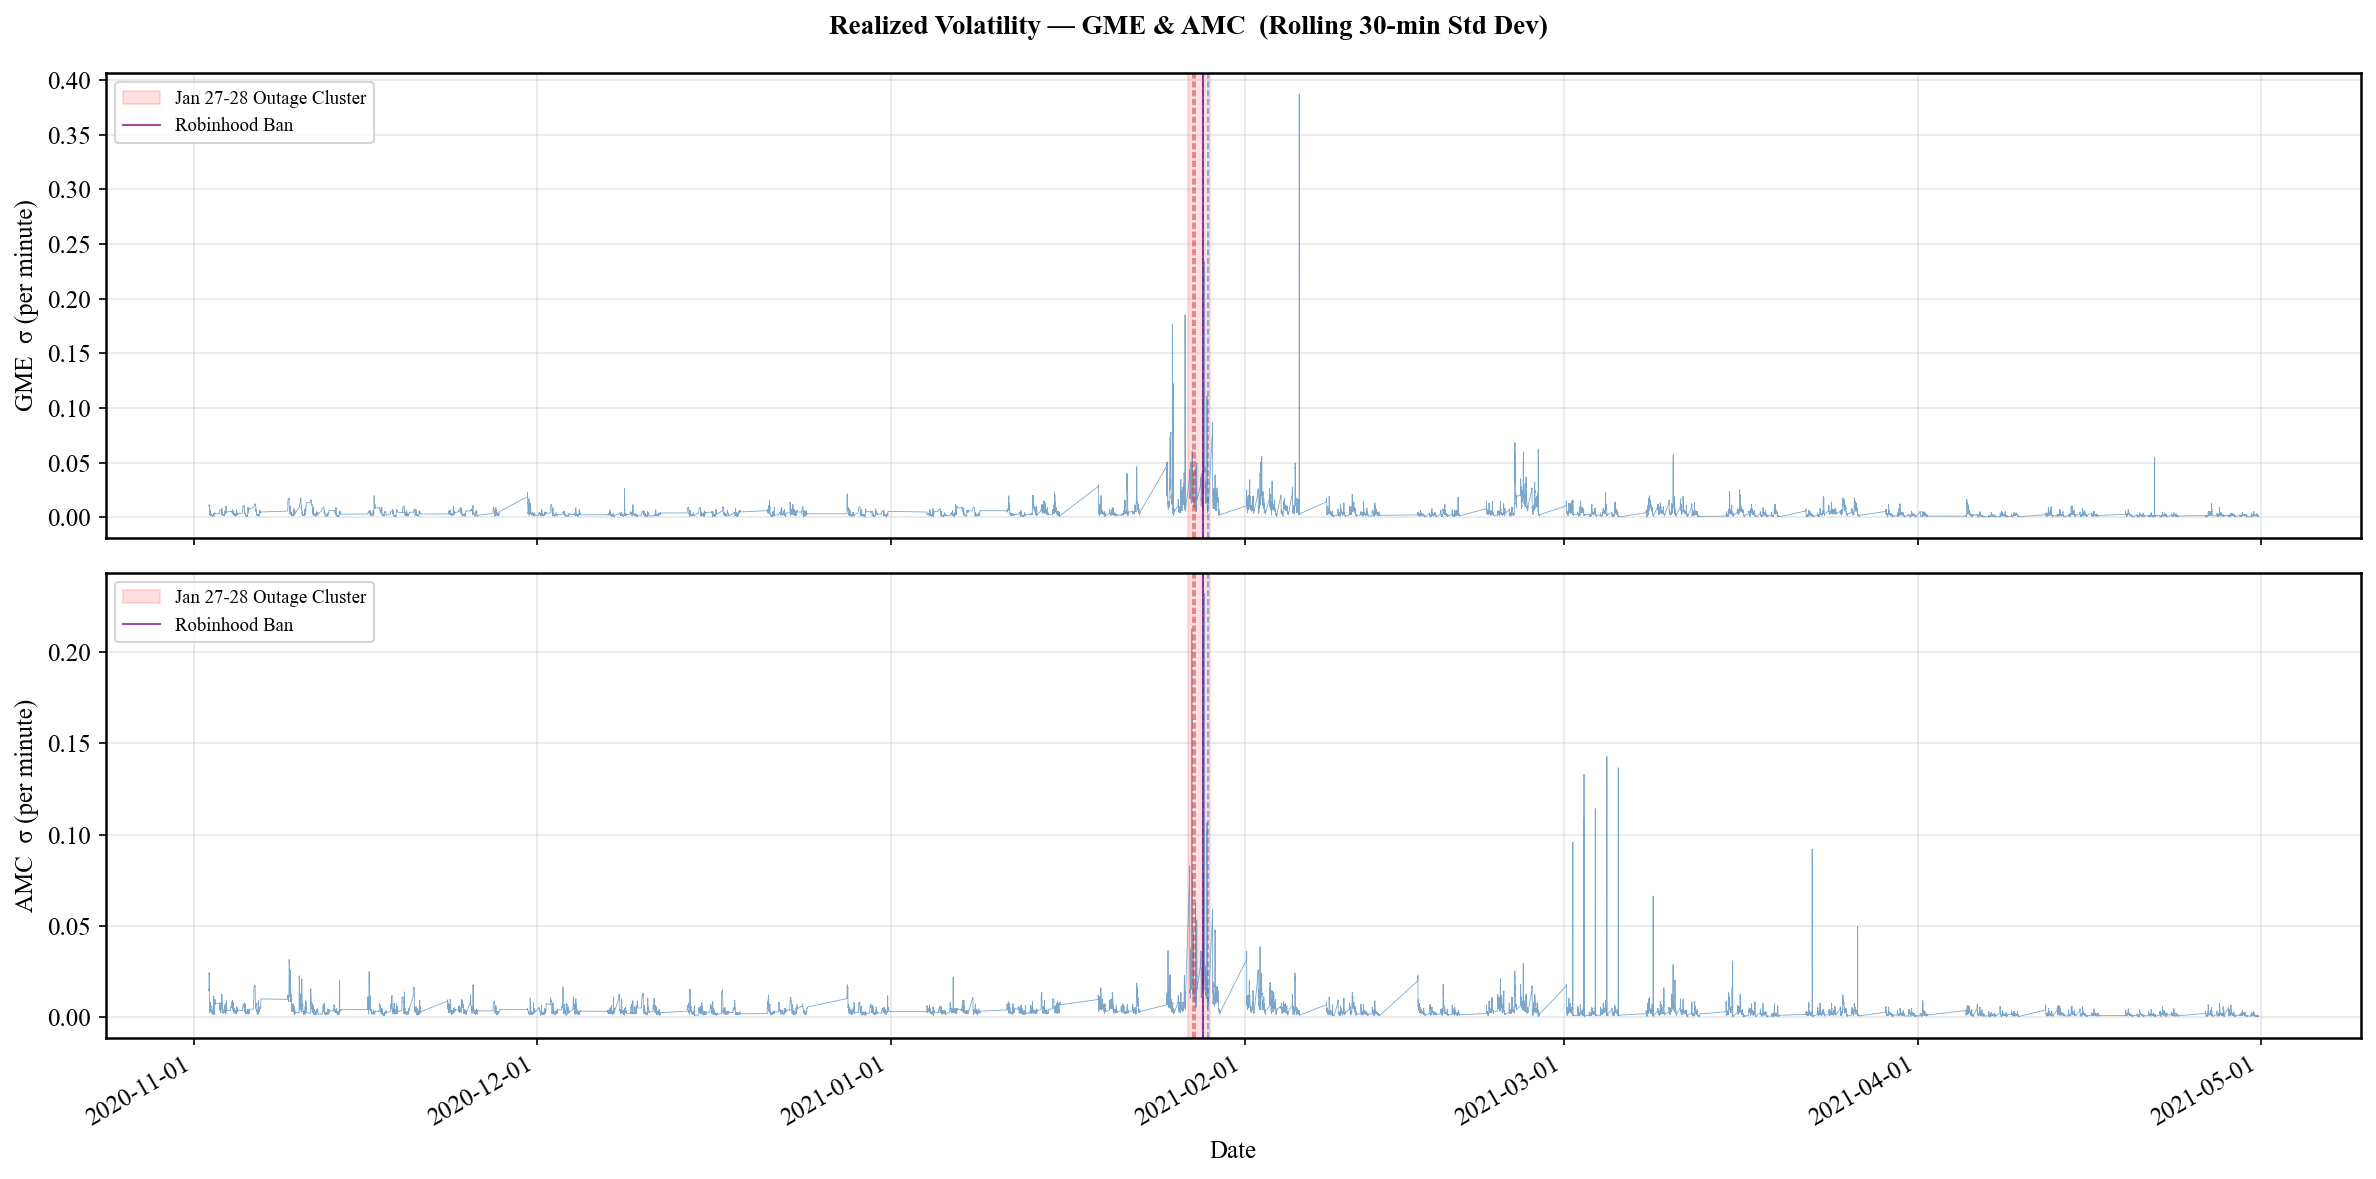

Saved: /Users/rajvardhan/Desktop/Projects/RA-MemeStocks/Rajvardhan workspace/output/ff4/figures/realized_volatility.png


In [20]:
def plot_realized_volatility(rolling_window_minutes=30):
    """
    Plot rolling realized volatility (std of minute returns) for GME and AMC
    over the full Nov 2020 – Apr 2021 sample period.
    """
    gme_vol = gme_data[STOCKS["GME"]["return_col"]].rolling(
        window=rolling_window_minutes, min_periods=rolling_window_minutes // 2
    ).std()
    amc_vol = amc_data[STOCKS["AMC"]["return_col"]].rolling(
        window=rolling_window_minutes, min_periods=rolling_window_minutes // 2
    ).std()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(
        f"Realized Volatility — GME & AMC  (Rolling {rolling_window_minutes}-min Std Dev)",
        fontsize=13, fontweight="bold"
    )

    cluster_start = pd.Timestamp("2021-01-27 00:00")
    cluster_end   = pd.Timestamp("2021-01-29 00:00")

    for ax, symbol, vol_series in [(ax1, "GME", gme_vol), (ax2, "AMC", amc_vol)]:
        ax.plot(vol_series.index, vol_series, color="steelblue",
                linewidth=0.4, alpha=0.7)
        ax.axvspan(cluster_start, cluster_end, alpha=0.12, color="red",
                   label="Jan 27-28 Outage Cluster")

        for evt in OUTAGE_EVENTS:
            color = PRE_BAN_COLOR if evt["pre_ban"] else POST_BAN_COLOR
            ax.axvline(evt["start"], color=color, linestyle="--",
                       linewidth=0.8, alpha=0.6)

        ax.axvline(ROBINHOOD_BAN_DATE, color="purple", linestyle="-",
                   linewidth=1.0, alpha=0.7, label="Robinhood Ban")

        ax.set_ylabel(f"{symbol}  σ (per minute)")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=9, loc="upper left")

    ax2.set_xlabel("Date")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()
    plt.tight_layout()

    out = FIGURES_DIR / "realized_volatility.png"
    fig.savefig(out)
    plt.show()
    print(f"Saved: {out}")


plot_realized_volatility()